# Hidden Markov Models — Detecció de règims de mercat

## 0. Objectiu del projecte

En aquest projecte estudiarem si un **Hidden Markov Model (HMM)** pot detectar diferents règims de mercat a partir de dades financeres.

La idea principal és que el mercat pot passar per períodes amb comportaments diferents:

- baixa volatilitat;
- alta volatilitat;
- retorns positius o negatius;
- fases més tranquil·les;
- fases de crisi o estrès.

Aquests règims no són directament observables.

Nosaltres només observem variables com els retorns o el rang diari dels preus.

L'HMM intentarà inferir un **estat ocult** del mercat a partir d'aquestes observacions.

La representació bàsica serà:

$$
Z_t = \text{estat ocult del mercat en el moment } t
$$

$$
X_t = \text{informació observable del mercat en el moment } t
$$

Per exemple, $X_t$ podria contenir:

$$
X_t =
\begin{bmatrix}
\text{retorn}_t \\
\text{rang}_t
\end{bmatrix}
$$

L'objectiu inicial **no és construir una estratègia de trading**.

Primer volem respondre una pregunta molt més bàsica:

> Pot un HMM identificar règims de mercat diferenciables, persistents i relativament estables?

Si la resposta és positiva, estudiarem després una segona pregunta:

> Conèixer la probabilitat del règim actual aporta informació sobre el risc o el comportament futur del mercat?

Només després d'aquestes dues fases estudiarem una possible aplicació econòmica.

---

## Hipòtesi de treball

Suposarem que existeix una variable no observable $Z_t$ que representa el règim del mercat.

Aquest estat evoluciona al llarg del temps segons unes probabilitats de transició:

$$
P(Z_t=j \mid Z_{t-1}=i)
$$

Per exemple, si el mercat està en un règim tranquil, podria tenir una probabilitat alta de continuar tranquil el dia següent.

Cada règim generarà observacions amb característiques diferents.

Per exemple:

$$
X_t \mid Z_t=k
\sim
\mathcal{N}(\mu_k,\Sigma_k)
$$

Això significa que cada estat $k$ tindrà la seva pròpia:

- mitjana;
- volatilitat;
- covariància entre variables.

L'HMM haurà d'aprendre aquestes característiques sense que nosaltres li indiquem prèviament quin règim correspon a cada dia.

---

## Regla important

Els números dels estats no tenen significat econòmic per si mateixos.

Un model pot anomenar:

- estat 0 → alta volatilitat;
- estat 1 → baixa volatilitat.

Un altre ajust podria intercanviar completament aquestes etiquetes.

Per tant:

$$
\boxed{
\text{estat 0 o estat 1}
\neq
\text{règim econòmic definit prèviament}
}
$$

Primer estimarem els estats.

Després estudiarem les seves característiques.

I només llavors els interpretarem.

---

## Regles de la recerca

Durant tot el projecte seguirem aquestes regles:

1. separar train, validation i test des del principi;
2. no utilitzar el test per seleccionar models;
3. evitar informació futura en la detecció dels règims;
4. començar amb models simples;
5. comparar sempre contra baselines més simples;
6. estudiar estabilitat, no només el millor resultat;
7. no construir una estratègia fins que el model estadístic estigui validat;
8. acceptar un resultat negatiu si els règims no són prou estables.

L'objectiu no és fabricar un backtest atractiu.

L'objectiu és entendre si la idea:

$$
\boxed{
\text{mercat}
\rightarrow
\text{règims ocults}
\rightarrow
\text{informació útil}
}
$$

té suport real en les dades.

## 1. Què és un Hidden Markov Model?

Un **Hidden Markov Model (HMM)** és un model que intenta descriure un sistema que va canviant entre diferents **estats ocults**.

Nosaltres no podem observar directament aquests estats.

Només podem observar les conseqüències que produeixen.

Una manera intuïtiva d'entendre-ho és pensar en el temps meteorològic.

Imaginem que existeixen dos estats:

- estat A → dia tranquil;
- estat B → dia de tempesta.

Nosaltres no podem veure directament "l'estat intern" de l'atmosfera.

Però sí que podem observar:

- temperatura;
- vent;
- pluja.

A partir d'aquestes observacions intentem inferir en quin estat ens trobem.

En un HMM tenim exactament aquesta estructura:

$$
\text{estat ocult}
\rightarrow
\text{observació visible}
$$

En mercats financers podríem imaginar:

$$
\text{règim de mercat}
\rightarrow
\text{retorn, volatilitat, rang, etc.}
$$

---

### 1.1 Els estats ocults

Anomenarem l'estat ocult en el moment $t$:

$$
Z_t
$$

Per exemple, amb dos règims:

$$
Z_t \in \{0,1\}
$$

Podríem acabar descobrint que:

- un estat té baixa volatilitat;
- l'altre té alta volatilitat.

Però això no ho decidirem nosaltres abans d'estimar el model.

L'HMM només veurà números.

---

### 1.2 Les observacions

La informació que sí podem observar serà:

$$
X_t
$$

En el cas més simple podríem utilitzar només el retorn diari:

$$
X_t=r_t
$$

on:

$$
r_t=
\log\left(
\frac{P_t}{P_{t-1}}
\right)
$$

Així tindríem:

$$
Z_t
\rightarrow
r_t
$$

L'estat ocult determina quina distribució és més probable que generi el retorn observat.

---

### 1.3 Distribució de cada estat

Suposem que tenim dos estats.

L'estat 0 podria generar retorns aproximadament així:

$$
r_t \mid Z_t=0
\sim
\mathcal{N}(\mu_0,\sigma_0^2)
$$

I l'estat 1:

$$
r_t \mid Z_t=1
\sim
\mathcal{N}(\mu_1,\sigma_1^2)
$$

Per exemple, podríem tenir:

$$
\mu_0 = 0.0005
$$

$$
\sigma_0 = 0.007
$$

i:

$$
\mu_1 = -0.001
$$

$$
\sigma_1 = 0.025
$$

Això descriuria dos comportaments diferents:

- estat 0 → retorn lleugerament positiu i poca volatilitat;
- estat 1 → retorn lleugerament negatiu i molta volatilitat.

Aquestes distribucions reben el nom de **distribucions d'emissió**.

---

### 1.4 La propietat de Markov

L'altra peça fonamental és que els estats tenen memòria.

L'HMM assumeix que el règim actual depèn directament del règim anterior:

$$
P(Z_t \mid Z_{t-1})
$$

i no necessita conèixer directament tota la història anterior.

Aquesta és la propietat de Markov.

La podem representar amb una matriu de transició.

Per exemple:

$$
A=
\begin{bmatrix}
0.97 & 0.03 \\
0.10 & 0.90
\end{bmatrix}
$$

La primera fila significa:

$$
P(Z_t=0 \mid Z_{t-1}=0)=0.97
$$

$$
P(Z_t=1 \mid Z_{t-1}=0)=0.03
$$

Per tant, si estem en l'estat 0:

- tenim un 97% de probabilitat de continuar-hi;
- tenim un 3% de probabilitat de passar a l'estat 1.

La segona fila significa que, si estem en l'estat 1:

- tenim un 10% de probabilitat de passar a l'estat 0;
- tenim un 90% de probabilitat de continuar a l'estat 1.

---

### 1.5 Per què això és interessant en mercats?

Els mercats financers tenen una característica important:

els períodes de volatilitat alta o baixa tendeixen a aparèixer en grups.

És a dir:

$$
\text{dia tranquil}
\rightarrow
\text{probabilitat elevada de continuar tranquil}
$$

i:

$$
\text{dia turbulent}
\rightarrow
\text{probabilitat elevada de continuar turbulent}
$$

Aquesta persistència temporal és precisament el que intenta capturar la matriu de transició.

Un model que només agrupés observacions segons el seu retorn o volatilitat podria detectar diferents tipus de dies.

Però l'HMM afegeix una idea extra:

$$
\boxed{
\text{l'ordre temporal també importa}
}
$$

---

### 1.6 Les tres peces bàsiques

Per tant, un HMM necessita aprendre principalment tres coses:

#### 1. Probabilitat inicial

En quin estat és probable començar:

$$
P(Z_1=k)
$$

#### 2. Matriu de transició

Com canvia el sistema entre estats:

$$
P(Z_t=j \mid Z_{t-1}=i)
$$

#### 3. Distribucions d'emissió

Quines observacions produeix cada estat:

$$
P(X_t \mid Z_t=k)
$$

Podem resumir-ho així:

$$
\boxed{
\text{HMM}
=
\text{estats}
+
\text{transicions}
+
\text{emissions}
}
$$

La nostra primera simulació consistirà precisament a crear nosaltres aquestes tres peces.

Com que coneixerem els estats reals, podrem comprovar després si el model és capaç de recuperar-los.

## 2. Simulació d'un mercat amb dos règims

Abans d'aplicar un HMM a dades reals, construirem un mercat artificial on nosaltres coneixem l'estat ocult real de cada dia.

Crearem dos règims.

### Règim 0

Representarà un mercat relativament tranquil:

$$
\mu_0 = 0.0005
$$

$$
\sigma_0 = 0.007
$$

És a dir:

- retorn mitjà diari lleugerament positiu;
- volatilitat baixa.

### Règim 1

Representarà un mercat turbulent:

$$
\mu_1 = -0.001
$$

$$
\sigma_1 = 0.025
$$

És a dir:

- retorn mitjà diari lleugerament negatiu;
- volatilitat molt superior.

La matriu de transició serà:

$$
A=
\begin{bmatrix}
0.97 & 0.03 \\
0.10 & 0.90
\end{bmatrix}
$$

Això farà que els règims siguin persistents.

Si estem en el règim 0, hi ha un 97% de probabilitat de continuar-hi el dia següent.

Si estem en el règim 1, hi ha un 90% de probabilitat de continuar-hi.

Per tant, no generarem simplement dies tranquils i turbulents de manera aleatòria.

Generarem **blocs temporals de règims**.

Aquesta és precisament la característica que més endavant haurà d'intentar descobrir l'HMM.

In [1]:
# SIMULACIO DELS REGIMS OCULTS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

n_dies = 2000

# Probabilitat inicial dels dos règims
prob_inicial = np.array([0.80, 0.20])

# Matriu de transició
transicio = np.array([
    [0.97, 0.03],
    [0.10, 0.90]
])

# Característiques dels retorns de cada règim
mu = np.array([0.0005, -0.0010])
sigma = np.array([0.007, 0.025])

# Vector on guardarem l'estat ocult real
estat = np.zeros(n_dies, dtype=int)

# Primer estat
estat[0] = rng.choice([0, 1], p=prob_inicial)

# Generem la seqüència d'estats
for t in range(1, n_dies):
    estat_anterior = estat[t - 1]

    estat[t] = rng.choice(
        [0, 1],
        p=transicio[estat_anterior]
    )

# Generem un retorn segons l'estat de cada dia
retorn = rng.normal(
    loc=mu[estat],
    scale=sigma[estat]
)

# Construïm un preu artificial
preu = 100 * np.exp(np.cumsum(retorn))

mercat = pd.DataFrame({
    "Estat_Real": estat,
    "Retorn": retorn,
    "Preu": preu
})

mercat.head()

,Estat_Real,Retorn,Preu
0,0,-0.006672,99.335050
1,0,0.006856,100.018475
2,0,-0.007919,99.229569
3,0,-0.001505,99.080384
4,0,-0.003602,98.724103


## 3. Comprovació dels règims simulats

Abans d'entrenar l'HMM, comprovarem què ha generat la simulació.

Com que coneixem l'estat real de cada dia, podem calcular per cada règim:

- nombre de dies;
- retorn mitjà;
- volatilitat;
- percentatge del temps.

Esperem trobar aproximadament:

$$
\text{Estat 0} \rightarrow \mu \approx 0.05\%, \quad \sigma \approx 0.7\%
$$

$$
\text{Estat 1} \rightarrow \mu \approx -0.10\%, \quad \sigma \approx 2.5\%
$$

No seran exactament aquests valors perquè només tenim una simulació finita.

In [2]:
# CARACTERISTIQUES DELS REGIMS REALS

resum_regims = (
    mercat
    .groupby("Estat_Real")["Retorn"]
    .agg(
        Dies="count",
        Retorn_Mitja="mean",
        Volatilitat="std"
    )
)

resum_regims["Percentatge_Temps"] = (
    resum_regims["Dies"] / len(mercat) * 100
)

resum_regims["Retorn_Mitja"] *= 100
resum_regims["Volatilitat"] *= 100

resum_regims.round(3)

,Dies,Retorn_Mitja,Volatilitat,Percentatge_Temps
Estat_Real,,,,
0,1532,0.045,0.690,76.6
1,468,0.170,2.555,23.4


## 4. Dades reals: SPY

A partir d'ara treballarem amb dades reals de l'ETF **SPY**.

Utilitzarem dues variables inicials:

### Retorn logarítmic diari

$$
r_t =
\log\left(
\frac{P_t}{P_{t-1}}
\right)
$$

### Rang intradiari

$$
q_t =
\log\left(
\frac{High_t}{Low_t}
\right)
$$

El retorn ens dona informació sobre el moviment del preu.

El rang ens dona informació sobre la intensitat o volatilitat del dia.

Separarem les dades cronològicament:

- **Train:** 2000–2014
- **Validation:** 2015–2019
- **Test:** 2020–actualitat

El test quedarà reservat i no l'utilitzarem per decidir el model.

In [3]:
# DADES REALS DE SPY

import yfinance as yf

spy = yf.download(
    "SPY",
    start="2000-01-01",
    auto_adjust=True,
    progress=False
)

# Per compatibilitat amb versions de yfinance que retornen MultiIndex
if isinstance(spy.columns, pd.MultiIndex):
    spy.columns = spy.columns.get_level_values(0)

spy = spy[["Open", "High", "Low", "Close"]].copy()

# Variables per al futur HMM
spy["Retorn_Log"] = np.log(
    spy["Close"] / spy["Close"].shift(1)
)

spy["Rang_Log"] = np.log(
    spy["High"] / spy["Low"]
)

spy = spy.dropna()

# Separació temporal
train = spy.loc[: "2014-12-31"].copy()
validation = spy.loc["2015-01-01":"2019-12-31"].copy()
test = spy.loc["2020-01-01":].copy()

print(f"Total:      {len(spy):,} dies")
print(f"Train:      {len(train):,} dies | {train.index.min().date()} → {train.index.max().date()}")
print(f"Validation: {len(validation):,} dies | {validation.index.min().date()} → {validation.index.max().date()}")
print(f"Test:       {len(test):,} dies | {test.index.min().date()} → {test.index.max().date()}")

spy.head()

Total:      6,726 dies
Train:      3,772 dies | 2000-01-04 → 2014-12-31
Validation: 1,258 dies | 2015-01-02 → 2019-12-31
Test:       1,696 dies | 2020-01-02 → 2026-10-01


Price,Open,High,Low,Close,Retorn_Log,Rang_Log
Date,,,,,,
2000-01-04,89.715494,90.047557,87.283624,87.351990,-0.039892,0.031175
2000-01-05,87.469181,88.465369,85.789335,87.508247,0.001787,0.030716
2000-01-06,87.273845,88.445831,86.101860,86.101860,-0.016202,0.026859
2000-01-07,87.703590,91.102348,87.547325,91.102348,0.056453,0.039804
2000-01-10,91.414848,91.825043,90.653058,91.414848,0.003424,0.012845


## 5. Primer HMM sobre dades reals

Començarem amb un HMM de **2 estats**.

El model només observarà:

$$
X_t =
\begin{bmatrix}
Retorn\_Log_t \\
Rang\_Log_t
\end{bmatrix}
$$

Abans d'entrenar-lo estandarditzarem les dues variables.

La mitjana i desviació utilitzades per estandarditzar es calcularan **només amb train**.

L'objectiu inicial és veure si el model descobreix dos comportaments estadístics diferents dins del mercat.

In [4]:
# INSTAL·LACIO DE LLIBRERIES HMM

%pip install -q scikit-learn hmmlearn

Note: you may need to restart the kernel to use updated packages.


In [5]:
# PRIMER HMM DE 2 ESTATS

from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

variables = ["Retorn_Log", "Rang_Log"]

scaler = StandardScaler()

X_train = scaler.fit_transform(
    train[variables]
)

hmm_2 = GaussianHMM(
    n_components=2,
    covariance_type="full",
    n_iter=500,
    random_state=42
)

hmm_2.fit(X_train)

print("Convergència:", hmm_2.monitor_.converged)
print("Iteracions:", hmm_2.monitor_.iter)

print("\nMatriu de transició:")
print(np.round(hmm_2.transmat_, 3))

Convergència: True
Iteracions: 20

Matriu de transició:
[[0.965 0.035]
 [0.085 0.915]]


## 6. Característiques dels estats detectats

L'HMM ha trobat dos estats persistents, però encara no sabem què representen econòmicament.

Analitzarem per cada estat:

- nombre de dies;
- retorn mitjà;
- volatilitat dels retorns;
- rang intradiari mitjà.

Aquesta classificació és retrospectiva i, de moment, només servirà per entendre el model.

No l'utilitzarem encara per fer trading.

In [6]:
# CARACTERISTIQUES DELS ESTATS HMM

train_hmm = train.copy()

# Estat més probable segons l'HMM
train_hmm["Estat_HMM"] = hmm_2.predict(X_train)

resum_estats = (
    train_hmm
    .groupby("Estat_HMM")
    .agg(
        Dies=("Retorn_Log", "count"),
        Retorn_Mitja=("Retorn_Log", "mean"),
        Volatilitat=("Retorn_Log", "std"),
        Rang_Mitja=("Rang_Log", "mean")
    )
)

resum_estats["Percentatge_Temps"] = (
    resum_estats["Dies"] / len(train_hmm) * 100
)

# Passem a percentatges per facilitar la lectura
for col in ["Retorn_Mitja", "Volatilitat", "Rang_Mitja"]:
    resum_estats[col] *= 100

resum_estats.round(3)

,Dies,Retorn_Mitja,Volatilitat,Rang_Mitja,Percentatge_Temps
Estat_HMM,,,,,
0,2685,0.072,0.720,1.006,71.182
1,1087,-0.121,2.114,2.569,28.818


## 7. Visualització dels règims detectats

Els dos estats trobats per l'HMM tenen característiques molt diferents.

En aquest ajust:

- **Estat 0:** règim tranquil i generalment positiu.
- **Estat 1:** règim turbulent i amb retorn mitjà negatiu.

Primer observarem simplement l'evolució del preu de SPY.

Després representarem el mateix mercat indicant visualment quin estat assigna l'HMM a cada període.

Aquesta visualització encara és retrospectiva: serveix per entendre què ha après el model, no per simular una decisió en temps real.

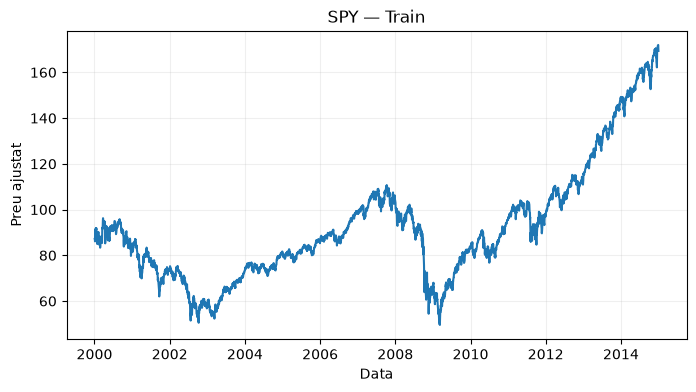

In [7]:
# EVOLUCIO DEL MERCAT

plt.figure(figsize=(8, 4))

plt.plot(
    train_hmm.index,
    train_hmm["Close"]
)

plt.title("SPY — Train")
plt.xlabel("Data")
plt.ylabel("Preu ajustat")
plt.grid(alpha=0.2)

plt.show()

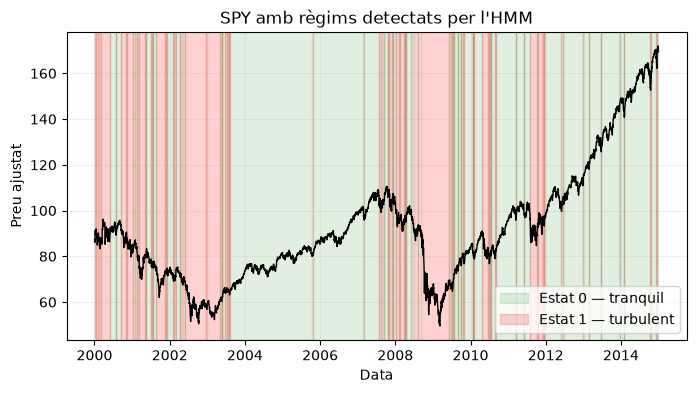

In [8]:
# REGIMS DETECTATS SOBRE EL MERCAT

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    train_hmm.index,
    train_hmm["Close"],
    color="black",
    linewidth=1
)

# Estat 0
ax.fill_between(
    train_hmm.index,
    0,
    1,
    where=(train_hmm["Estat_HMM"] == 0),
    transform=ax.get_xaxis_transform(),
    color="green",
    alpha=0.12,
    label="Estat 0 — tranquil"
)

# Estat 1
ax.fill_between(
    train_hmm.index,
    0,
    1,
    where=(train_hmm["Estat_HMM"] == 1),
    transform=ax.get_xaxis_transform(),
    color="red",
    alpha=0.18,
    label="Estat 1 — turbulent"
)

ax.set_title("SPY amb règims detectats per l'HMM")
ax.set_xlabel("Data")
ax.set_ylabel("Preu ajustat")
ax.legend()
ax.grid(alpha=0.2)

plt.show()

## 8. L'HMM detecta règims o només volatilitat?

Visualment els estats semblen molt coherents amb períodes de calma i turbulència.

Però això planteja una pregunta important:

> L'HMM està descobrint una estructura temporal pròpia o simplement està separant dies de baixa i alta volatilitat?

Calcularem una volatilitat rolling de 20 dies:

$$
\sigma_{20,t}
=
Std(r_{t-19},...,r_t)\sqrt{252}
$$

i compararem aquesta volatilitat amb els estats detectats.

Si els dos estats presenten distribucions de volatilitat molt diferents, sabrem que la volatilitat és una part important del que està capturant el model.

Més endavant compararem l'HMM amb un model que no utilitza transicions temporals.

Volatilitat anualitzada rolling 20 dies (%)


,Mitjana,Mediana,Min,Max
Estat_HMM,,,,
0,12.87,11.88,4.35,32.26
1,28.53,24.71,10.02,93.97


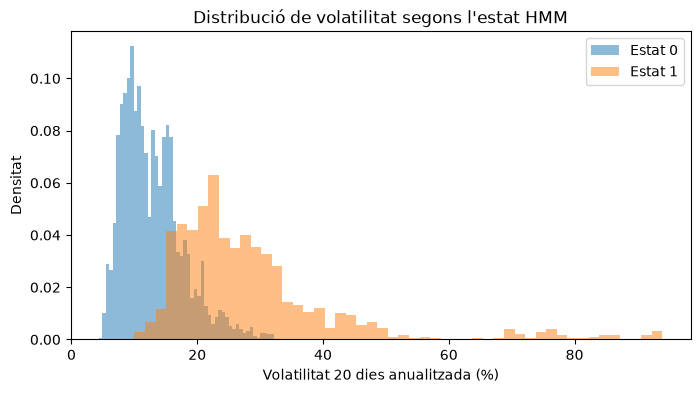

In [9]:
# HMM VS VOLATILITAT

train_hmm["Vol_20"] = (
    train_hmm["Retorn_Log"]
    .rolling(20)
    .std()
    * np.sqrt(252)
    * 100
)

resum_vol = (
    train_hmm
    .groupby("Estat_HMM")["Vol_20"]
    .agg(
        Mitjana="mean",
        Mediana="median",
        Min="min",
        Max="max"
    )
)

print("Volatilitat anualitzada rolling 20 dies (%)")
display(resum_vol.round(2))

plt.figure(figsize=(8, 4))

for estat in [0, 1]:
    dades = train_hmm.loc[
        train_hmm["Estat_HMM"] == estat,
        "Vol_20"
    ].dropna()

    plt.hist(
        dades,
        bins=50,
        alpha=0.5,
        density=True,
        label=f"Estat {estat}"
    )

plt.title("Distribució de volatilitat segons l'estat HMM")
plt.xlabel("Volatilitat 20 dies anualitzada (%)")
plt.ylabel("Densitat")
plt.legend()

plt.show()

## 9. HMM vs model sense memòria temporal

Compararem l'HMM amb un **Gaussian Mixture Model (GMM)** de dos grups.

Els dos models veuran exactament les mateixes variables:

$$
X_t =
\begin{bmatrix}
Retorn\_Log_t \\
Rang\_Log_t
\end{bmatrix}
$$

La diferència és:

$$
\text{GMM} \rightarrow \text{classifica cada dia independentment}
$$

$$
\text{HMM} \rightarrow \text{també considera la persistència temporal dels estats}
$$

Si els dos models produeixen pràcticament el mateix resultat, la part de Markov estaria aportant poc.

Si l'HMM genera règims més persistents i coherents, tindrem evidència que l'ordre temporal aporta informació.

In [10]:
# HMM VS GMM SENSE MEMORIA TEMPORAL

from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=2,
    covariance_type="full",
    random_state=42
)

gmm.fit(X_train)

train_hmm["Estat_GMM"] = gmm.predict(X_train)

# Identifiquem quin estat GMM és el de major volatilitat/rang
rang_per_estat = (
    train_hmm
    .groupby("Estat_GMM")["Rang_Log"]
    .mean()
)

estat_gmm_turbulent = rang_per_estat.idxmax()

train_hmm["GMM_Turbulent"] = (
    train_hmm["Estat_GMM"] == estat_gmm_turbulent
).astype(int)

# En el nostre HMM l'estat 1 és el turbulent
train_hmm["HMM_Turbulent"] = (
    train_hmm["Estat_HMM"] == 1
).astype(int)

coincidencia = (
    train_hmm["HMM_Turbulent"]
    == train_hmm["GMM_Turbulent"]
).mean()

transicions_hmm = (
    train_hmm["HMM_Turbulent"]
    .diff()
    .abs()
    .fillna(0)
    .sum()
)

transicions_gmm = (
    train_hmm["GMM_Turbulent"]
    .diff()
    .abs()
    .fillna(0)
    .sum()
)

print(f"Coincidència HMM vs GMM: {coincidencia:.2%}")
print(f"Transicions HMM: {transicions_hmm:.0f}")
print(f"Transicions GMM: {transicions_gmm:.0f}")

Coincidència HMM vs GMM: 87.01%
Transicions HMM: 135
Transicions GMM: 721


## 10. Probabilitats filtrades: eliminar informació futura

Fins ara hem utilitzat la seqüència completa per identificar els estats.

Això és útil per estudiar el model, però no representa una situació real.

En el moment $t$ només coneixem:

$$
X_1,\ldots,X_t
$$

Per tant, necessitem calcular:

$$
P(Z_t=k \mid X_1,\ldots,X_t)
$$

Aquesta probabilitat s'anomena **probabilitat filtrada**.

La diferència és:

$$
\text{retrospectiu}
\rightarrow
\text{pot utilitzar informació futura}
$$

$$
\text{filtrat}
\rightarrow
\text{només utilitza passat i present}
$$

A partir d'ara, aquesta serà la informació que podrem considerar disponible en temps real.

In [11]:
# PROBABILITATS FILTRADES SENSE LOOKAHEAD

from scipy.stats import multivariate_normal

X_validation = scaler.transform(
    validation[variables]
)

def probabilitats_filtrades(model, X):

    n = len(X)
    k = model.n_components

    probabilitats = np.zeros((n, k))

    # Probabilitat de les observacions sota cada estat
    emissions = np.zeros((n, k))

    for estat in range(k):
        emissions[:, estat] = multivariate_normal.pdf(
            X,
            mean=model.means_[estat],
            cov=model.covars_[estat],
            allow_singular=True
        )

    # Primer dia
    alpha = model.startprob_ * emissions[0]
    alpha /= alpha.sum()

    probabilitats[0] = alpha

    # Dies següents
    for t in range(1, n):

        alpha = (
            alpha @ model.transmat_
        ) * emissions[t]

        alpha /= alpha.sum()

        probabilitats[t] = alpha

    return probabilitats


prob_val = probabilitats_filtrades(
    hmm_2,
    X_validation
)

validation_hmm = validation.copy()

validation_hmm["Prob_Estat_0"] = prob_val[:, 0]
validation_hmm["Prob_Estat_1"] = prob_val[:, 1]

validation_hmm[
    ["Retorn_Log", "Rang_Log", "Prob_Estat_0", "Prob_Estat_1"]
].head(10).round(3)

Price,Retorn_Log,Rang_Log,Prob_Estat_0,Prob_Estat_1
Date,,,,
2015-01-02,-0.001,0.013,0.000,1.000
2015-01-05,-0.018,0.015,0.036,0.964
2015-01-06,-0.009,0.019,0.066,0.934
2015-01-07,0.012,0.009,0.512,0.488
2015-01-08,0.018,0.011,0.621,0.379
2015-01-09,-0.008,0.014,0.893,0.107
2015-01-12,-0.008,0.013,0.977,0.023
2015-01-13,-0.003,0.024,0.287,0.713
2015-01-14,-0.006,0.013,0.819,0.181


## 11. Filtrat continu entre train i validation

Els paràmetres de l'HMM es mantenen congelats després del train.

Però l'estat probabilístic no s'ha de reiniciar quan comença validation.

La probabilitat del primer dia de validation ha de dependre també de tot el que el model havia observat fins al final del train.

Per tant, filtrarem de manera contínua:

$$
\text{train}
\rightarrow
\text{validation}
$$

mantenint els mateixos paràmetres estimats només amb train.

Això continua sense introduir lookahead.

In [12]:
# FILTRAT CONTINU TRAIN + VALIDATION

dades_filtrat = pd.concat([
    train[variables],
    validation[variables]
])

X_filtrat = scaler.transform(dades_filtrat)

prob_filtrat = probabilitats_filtrades(
    hmm_2,
    X_filtrat
)

prob_filtrat = pd.DataFrame(
    prob_filtrat,
    index=dades_filtrat.index,
    columns=["Prob_Estat_0", "Prob_Estat_1"]
)

validation_hmm = validation.copy()

validation_hmm[
    ["Prob_Estat_0", "Prob_Estat_1"]
] = prob_filtrat.loc[validation.index]

validation_hmm[
    ["Retorn_Log", "Rang_Log", "Prob_Estat_0", "Prob_Estat_1"]
].head(10).round(3)

Price,Retorn_Log,Rang_Log,Prob_Estat_0,Prob_Estat_1
Date,,,,
2015-01-02,-0.001,0.013,0.996,0.004
2015-01-05,-0.018,0.015,0.909,0.091
2015-01-06,-0.009,0.019,0.804,0.196
2015-01-07,0.012,0.009,0.960,0.040
2015-01-08,0.018,0.011,0.950,0.050
2015-01-09,-0.008,0.014,0.983,0.017
2015-01-12,-0.008,0.013,0.992,0.008
2015-01-13,-0.003,0.024,0.347,0.653
2015-01-14,-0.006,0.013,0.851,0.149


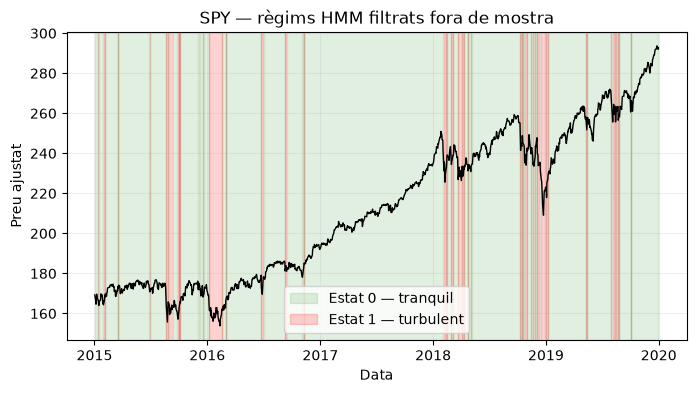

In [13]:
# REGIMS FILTRATS A VALIDATION

validation_hmm["Estat_Filtrat"] = (
    validation_hmm["Prob_Estat_1"] > 0.5
).astype(int)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    validation_hmm.index,
    validation_hmm["Close"],
    color="black",
    linewidth=1
)

ax.fill_between(
    validation_hmm.index,
    0,
    1,
    where=(validation_hmm["Estat_Filtrat"] == 0),
    transform=ax.get_xaxis_transform(),
    color="green",
    alpha=0.12,
    label="Estat 0 — tranquil"
)

ax.fill_between(
    validation_hmm.index,
    0,
    1,
    where=(validation_hmm["Estat_Filtrat"] == 1),
    transform=ax.get_xaxis_transform(),
    color="red",
    alpha=0.18,
    label="Estat 1 — turbulent"
)

ax.set_title("SPY — règims HMM filtrats fora de mostra")
ax.set_xlabel("Data")
ax.set_ylabel("Preu ajustat")
ax.legend()
ax.grid(alpha=0.2)

plt.show()

## 12. Primer model basat en règims

Construirem una primera aplicació molt simple de l'HMM.

No intentarem predir si SPY pujarà o baixarà.

Utilitzarem el règim com una mesura de risc.

Definirem:

$$
w_{t+1}
=
1-P(Z_t=\text{turbulent})
$$

on $w$ és l'exposició a SPY.

Per exemple:

$$
P(\text{turbulent})=0.80
\rightarrow
w=0.20
$$

El model mantindrà molta exposició durant règims tranquils i reduirà risc quan augmenti la probabilitat del règim turbulent.

La probabilitat observada al dia $t$ s'aplicarà al retorn del dia següent per evitar lookahead.

De moment ignorarem costos. Primer volem entendre el comportament brut del model.

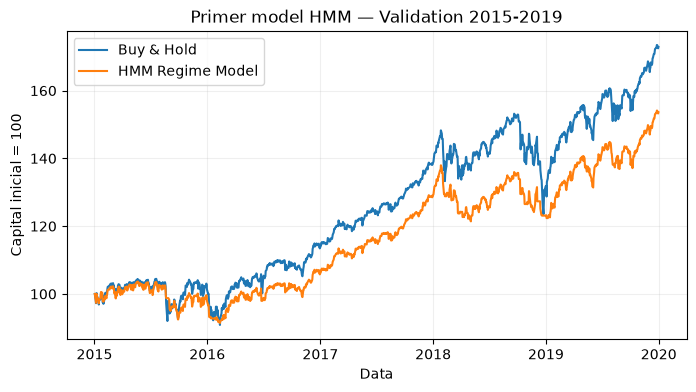

Exposició mitjana: 88.2%


In [14]:
# PRIMER MODEL DE REGIMS

model_regim = validation_hmm.copy()

# Retorn simple de SPY
model_regim["Retorn_SPY"] = (
    model_regim["Close"]
    .pct_change()
)

# Exposició decidida amb la informació del dia anterior
model_regim["Exposicio"] = (
    1 - model_regim["Prob_Estat_1"]
).shift(1)

model_regim["Exposicio"] = (
    model_regim["Exposicio"]
    .fillna(0)
)

# Retorn de l'estratègia
model_regim["Retorn_Model"] = (
    model_regim["Exposicio"]
    * model_regim["Retorn_SPY"]
)

# Corbes de capital
model_regim["Capital_SPY"] = (
    100 * (1 + model_regim["Retorn_SPY"].fillna(0)).cumprod()
)

model_regim["Capital_Model"] = (
    100 * (1 + model_regim["Retorn_Model"].fillna(0)).cumprod()
)

plt.figure(figsize=(8, 4))

plt.plot(
    model_regim.index,
    model_regim["Capital_SPY"],
    label="Buy & Hold"
)

plt.plot(
    model_regim.index,
    model_regim["Capital_Model"],
    label="HMM Regime Model"
)

plt.title("Primer model HMM — Validation 2015-2019")
plt.ylabel("Capital inicial = 100")
plt.xlabel("Data")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

print(
    f"Exposició mitjana: "
    f"{model_regim['Exposicio'].mean():.1%}"
)

## 13. Model direccional HMM Long / Short

Fins ara l'HMM s'ha utilitzat com un filtre de risc.

Ara provarem una aplicació diferent:

$$
\boxed{
\text{predir la direcció esperada del pròxim retorn}
}
$$

Cada estat té un retorn mitjà estimat:

$$
\mu_0,\mu_1
$$

En el moment $t$ coneixem les probabilitats filtrades dels estats.

Primer utilitzarem la matriu de transició per estimar la probabilitat dels estats del dia següent:

$$
p_{t+1|t}
=
p_t A
$$

Després calcularem el retorn esperat:

$$
E[r_{t+1}]
=
\sum_k
P(Z_{t+1}=k \mid X_{1:t})
\mu_k
$$

La posició serà:

$$
w_{t+1}
=
\begin{cases}
+1 & E[r_{t+1}]>0 \\
-1 & E[r_{t+1}]<0
\end{cases}
$$

Per tant, el model estarà sempre:

- 100% long, o
- 100% short.

Això converteix l'HMM en un model direccional, no només en un filtre de volatilitat.

Retorn log mitjà per estat:
Estat 0: 0.0735%
Estat 1: -0.1217%


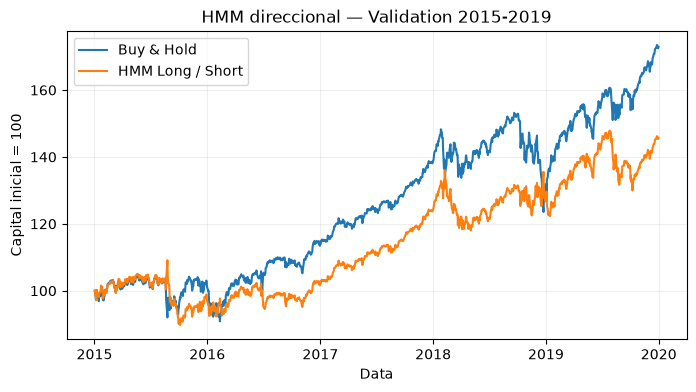

Temps Long:  87.5%
Temps Short: 12.5%


In [15]:
# MODEL HMM DIRECCIONAL LONG SHORT

# Mitjanes dels estats convertides de nou a escala real
mitjanes_originals = (
    hmm_2.means_ * scaler.scale_
    + scaler.mean_
)

# Retorn log mitjà de cada estat
mu_retorn_estats = mitjanes_originals[:, 0]

print("Retorn log mitjà per estat:")
for estat, mu_estat in enumerate(mu_retorn_estats):
    print(f"Estat {estat}: {mu_estat * 100:.4f}%")

# Probabilitats filtrades actuals
prob_actual = validation_hmm[
    ["Prob_Estat_0", "Prob_Estat_1"]
].values

# Probabilitat dels règims del dia següent
prob_seguent = prob_actual @ hmm_2.transmat_

# Retorn esperat del dia següent
retorn_esperat = prob_seguent @ mu_retorn_estats

model_direccional = validation_hmm.copy()

model_direccional["Retorn_Esperat"] = retorn_esperat

# +1 long / -1 short
model_direccional["Posicio"] = np.where(
    model_direccional["Retorn_Esperat"] >= 0,
    1.0,
    -1.0
)

# La decisió de t s'aplica al retorn de t+1
model_direccional["Posicio_Aplicada"] = (
    model_direccional["Posicio"].shift(1)
)

model_direccional["Retorn_SPY"] = (
    model_direccional["Close"].pct_change()
)

model_direccional["Retorn_Model"] = (
    model_direccional["Posicio_Aplicada"]
    * model_direccional["Retorn_SPY"]
)

model_direccional["Capital_Model"] = (
    100
    * (1 + model_direccional["Retorn_Model"].fillna(0))
    .cumprod()
)

model_direccional["Capital_SPY"] = (
    100
    * (1 + model_direccional["Retorn_SPY"].fillna(0))
    .cumprod()
)

plt.figure(figsize=(8, 4))

plt.plot(
    model_direccional.index,
    model_direccional["Capital_SPY"],
    label="Buy & Hold"
)

plt.plot(
    model_direccional.index,
    model_direccional["Capital_Model"],
    label="HMM Long / Short"
)

plt.title("HMM direccional — Validation 2015-2019")
plt.ylabel("Capital inicial = 100")
plt.xlabel("Data")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

print(
    f"Temps Long:  "
    f"{(model_direccional['Posicio'] == 1).mean():.1%}"
)

print(
    f"Temps Short: "
    f"{(model_direccional['Posicio'] == -1).mean():.1%}"
)

## 14. Què prediu realment el règim?

El règim turbulent presenta retorns històrics més negatius, però això no implica necessàriament capacitat per predir la direcció del dia següent.

Estudiarem si la probabilitat actual del règim turbulent està relacionada amb:

- retorn del dia següent;
- retorn dels pròxims 5 dies;
- retorn dels pròxims 20 dies;
- volatilitat dels pròxims 20 dies.

La pregunta és:

$$
P(Z_t=\text{turbulent})
\rightarrow
\text{què ens diu sobre el futur?}
$$

Si prediu principalment volatilitat i no retorn, utilitzarem l'HMM com a model de risc i no com a model direccional.

In [16]:
# CAPACITAT PREDICTIVA DEL REGIM

analisi = validation_hmm.copy()

analisi["Prob_Turbulent"] = analisi["Prob_Estat_1"]

# Retorns futurs
analisi["Retorn_Futur_1d"] = (
    analisi["Close"].shift(-1) / analisi["Close"] - 1
)

analisi["Retorn_Futur_5d"] = (
    analisi["Close"].shift(-5) / analisi["Close"] - 1
)

analisi["Retorn_Futur_20d"] = (
    analisi["Close"].shift(-20) / analisi["Close"] - 1
)

# Volatilitat futura dels següents 20 dies
retorns = analisi["Close"].pct_change()

analisi["Vol_Futura_20d"] = (
    retorns
    .rolling(20)
    .std()
    .shift(-20)
    * np.sqrt(252)
)

# Dividim les probabilitats en 5 grups
analisi["Grup_Prob"] = pd.qcut(
    analisi["Prob_Turbulent"],
    q=5,
    duplicates="drop"
)

resum_predictiu = (
    analisi
    .groupby("Grup_Prob", observed=True)
    .agg(
        Dies=("Prob_Turbulent", "count"),
        Prob_Turbulent=("Prob_Turbulent", "mean"),
        Retorn_1d=("Retorn_Futur_1d", "mean"),
        Retorn_5d=("Retorn_Futur_5d", "mean"),
        Retorn_20d=("Retorn_Futur_20d", "mean"),
        Vol_Futura_20d=("Vol_Futura_20d", "mean")
    )
)

for col in [
    "Prob_Turbulent",
    "Retorn_1d",
    "Retorn_5d",
    "Retorn_20d",
    "Vol_Futura_20d"
]:
    resum_predictiu[col] *= 100

resum_predictiu.round(2)

,Dies,Prob_Turbulent,Retorn_1d,Retorn_5d,Retorn_20d,Vol_Futura_20d
Grup_Prob,,,,,,
"(0.0009699999999999999, 0.00263]",252,0.23,0.08,0.11,0.50,11.25
"(0.00263, 0.00336]",251,0.30,0.07,0.26,0.81,10.29
"(0.00336, 0.00461]",252,0.39,0.03,0.10,0.75,10.00
"(0.00461, 0.0292]",251,0.91,0.02,0.29,1.06,11.39
"(0.0292, 1.0]",252,56.48,0.04,0.45,1.54,17.13


## 15. HMM com a model de risc

L'anàlisi anterior mostra que la probabilitat del règim turbulent no prediu clarament retorns negatius.

En canvi, sí que està relacionada amb una volatilitat futura més elevada.

Per tant, utilitzarem l'HMM per estimar el risc del dia següent.

Primer calcularem la probabilitat prevista de cada estat:

$$
p_{t+1|t}=p_tA
$$

Cada estat té una volatilitat pròpia:

$$
\sigma_0,\sigma_1
$$

Podem estimar la variància esperada del dia següent:

$$
E[\sigma^2_{t+1}]
=
\sum_k
p_{t+1|t,k}\sigma_k^2
$$

Després ajustarem l'exposició per intentar mantenir una volatilitat objectiu.

Això utilitza l'HMM per allò que sembla detectar millor:

$$
\boxed{
\text{règim}
\rightarrow
\text{risc futur}
\rightarrow
\text{exposició}
}
$$

Volatilitat diària estimada:
Estat 0: 0.71% diària | 11.3% anual
Estat 1: 2.11% diària | 33.4% anual


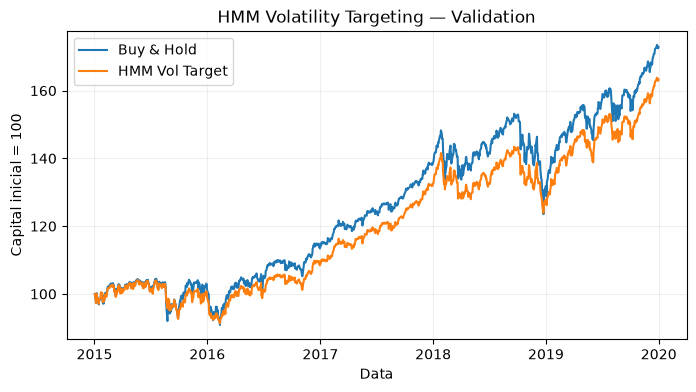

Exposició mitjana: 93.2%


In [17]:
# HMM VOLATILITY TARGETING

# Desviació del retorn de cada estat en escala original
sigma_estats = []

for estat in range(hmm_2.n_components):
    var_estandarditzada = hmm_2.covars_[estat][0, 0]

    sigma_original = (
        np.sqrt(var_estandarditzada)
        * scaler.scale_[0]
    )

    sigma_estats.append(sigma_original)

sigma_estats = np.array(sigma_estats)

print("Volatilitat diària estimada:")
for estat, sigma in enumerate(sigma_estats):
    print(
        f"Estat {estat}: "
        f"{sigma * 100:.2f}% diària | "
        f"{sigma * np.sqrt(252) * 100:.1f}% anual"
    )

# Probabilitat actual
prob_actual = validation_hmm[
    ["Prob_Estat_0", "Prob_Estat_1"]
].values

# Predicció dels estats de demà
prob_seguent = prob_actual @ hmm_2.transmat_

# Variància esperada
variancia_esperada = (
    prob_seguent @ (sigma_estats ** 2)
)

vol_esperada_anual = (
    np.sqrt(variancia_esperada)
    * np.sqrt(252)
)

model_risc = validation_hmm.copy()

model_risc["Vol_Prevista"] = vol_esperada_anual

# Objectiu: 15% anual
vol_objectiu = 0.15

model_risc["Exposicio"] = (
    vol_objectiu / model_risc["Vol_Prevista"]
).clip(upper=1.0)

# Decisió de t aplicada a t+1
model_risc["Exposicio_Aplicada"] = (
    model_risc["Exposicio"].shift(1)
)

model_risc["Retorn_SPY"] = (
    model_risc["Close"].pct_change()
)

model_risc["Retorn_Model"] = (
    model_risc["Exposicio_Aplicada"]
    * model_risc["Retorn_SPY"]
)

model_risc["Capital_SPY"] = (
    100
    * (1 + model_risc["Retorn_SPY"].fillna(0))
    .cumprod()
)

model_risc["Capital_Model"] = (
    100
    * (1 + model_risc["Retorn_Model"].fillna(0))
    .cumprod()
)

plt.figure(figsize=(8, 4))

plt.plot(
    model_risc.index,
    model_risc["Capital_SPY"],
    label="Buy & Hold"
)

plt.plot(
    model_risc.index,
    model_risc["Capital_Model"],
    label="HMM Vol Target"
)

plt.title("HMM Volatility Targeting — Validation")
plt.ylabel("Capital inicial = 100")
plt.xlabel("Data")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

print(
    f"Exposició mitjana: "
    f"{model_risc['Exposicio_Aplicada'].mean():.1%}"
)

## 16. Comparació justa del model HMM

Una estratègia amb menys exposició mitjana no es pot comparar només pel capital final amb Buy & Hold.

Compararem:

- CAGR;
- volatilitat anualitzada;
- Sharpe;
- màxim drawdown.

També afegirem un benchmark amb la mateixa exposició mitjana que l'HMM.

Això permet separar:

$$
\text{benefici de detectar règims}
$$

de:

$$
\text{benefici de simplement tenir menys exposició}
$$

In [18]:
# METRIQUES I BENCHMARK D'EXPOSICIO CONSTANT

def max_drawdown(retorns):
    capital = (1 + retorns.fillna(0)).cumprod()
    maxim = capital.cummax()
    drawdown = capital / maxim - 1
    return drawdown.min()

def metriques(retorns):
    retorns = retorns.dropna()

    anys = len(retorns) / 252
    capital_final = (1 + retorns).prod()

    cagr = capital_final ** (1 / anys) - 1
    vol = retorns.std() * np.sqrt(252)

    sharpe = (
        retorns.mean() / retorns.std() * np.sqrt(252)
        if retorns.std() > 0 else np.nan
    )

    dd = max_drawdown(retorns)

    return {
        "CAGR": cagr,
        "Volatilitat": vol,
        "Sharpe": sharpe,
        "Max_Drawdown": dd
    }


exposicio_mitjana = (
    model_risc["Exposicio_Aplicada"].mean()
)

model_risc["Retorn_Constant"] = (
    exposicio_mitjana
    * model_risc["Retorn_SPY"]
)

resultats = pd.DataFrame({
    "Buy & Hold": metriques(
        model_risc["Retorn_SPY"]
    ),
    "Exposicio constant": metriques(
        model_risc["Retorn_Constant"]
    ),
    "HMM Vol Target": metriques(
        model_risc["Retorn_Model"]
    )
}).T

resultats["CAGR"] *= 100
resultats["Volatilitat"] *= 100
resultats["Max_Drawdown"] *= 100

resultats.round(2)

,CAGR,Volatilitat,Sharpe,Max_Drawdown
Buy & Hold,11.60,13.43,0.88,-19.35
Exposicio constant,10.84,12.51,0.88,-18.13
HMM Vol Target,10.33,11.08,0.94,-13.64


## 17. Comparació a igual risc

El model HMM ha generat menys rendibilitat absoluta, però també ha assumit menys risc.

Per fer una comparació més justa, podem escalar l'exposició del model fins que tingui aproximadament la mateixa volatilitat que Buy & Hold.

Definirem:

$$
L=
\frac{\sigma_{B\&H}}
{\sigma_{HMM}}
$$

En el nostre cas:

$$
L \approx
\frac{13.43}{11.08}
\approx 1.21
$$

Per tant, provarem el model HMM amb aproximadament 1.21 vegades la seva exposició original.

Si a igual volatilitat el model aconsegueix més rendibilitat o menys drawdown, tindrem una evidència més forta que la detecció de règims aporta valor.

In [19]:
# HMM AMB RISC IGUALAT A BUY AND HOLD

vol_bh = (
    model_risc["Retorn_SPY"].std()
    * np.sqrt(252)
)

vol_hmm = (
    model_risc["Retorn_Model"].std()
    * np.sqrt(252)
)

leverage = vol_bh / vol_hmm

model_risc["Retorn_HMM_Leveraged"] = (
    model_risc["Retorn_Model"]
    * leverage
)

resultats_igual_risc = pd.DataFrame({
    "Buy & Hold": metriques(
        model_risc["Retorn_SPY"]
    ),
    "HMM original": metriques(
        model_risc["Retorn_Model"]
    ),
    "HMM igual risc": metriques(
        model_risc["Retorn_HMM_Leveraged"]
    )
}).T

resultats_igual_risc["CAGR"] *= 100
resultats_igual_risc["Volatilitat"] *= 100
resultats_igual_risc["Max_Drawdown"] *= 100

print(f"Leverage aplicat: {leverage:.2f}x")

resultats_igual_risc.round(2)

Leverage aplicat: 1.21x


,CAGR,Volatilitat,Sharpe,Max_Drawdown
Buy & Hold,11.60,13.43,0.88,-19.35
HMM original,10.33,11.08,0.94,-13.64
HMM igual risc,12.47,13.43,0.94,-16.35


## 18. HMM vs volatility targeting simple

L'HMM a igual risc ha millorat el resultat de Buy & Hold durant validation.

Però sabem que l'HMM detecta principalment canvis de volatilitat.

Per tant, necessitem comprovar si la seva complexitat aporta alguna cosa respecte a una regla molt més simple.

Construirem un baseline basat només en la volatilitat observada dels últims 20 dies:

$$
w_{t+1}
=
\frac{\sigma_{objectiu}}
{\sigma_{20,t}}
$$

limitant inicialment l'exposició màxima a 100%.

Després escalarem tant el model simple com l'HMM fins a la mateixa volatilitat de Buy & Hold.

La pregunta és:

$$
\boxed{
\text{HMM}
\stackrel{?}{>}
\text{volatility targeting simple}
}
$$

In [20]:
# HMM VS VOLATILITY TARGETING SIMPLE

dades_vol = pd.concat([
    train[["Close"]],
    validation[["Close"]]
]).copy()

dades_vol["Retorn"] = dades_vol["Close"].pct_change()

# Volatilitat observada amb els últims 20 dies
dades_vol["Vol_20"] = (
    dades_vol["Retorn"]
    .rolling(20)
    .std()
    * np.sqrt(252)
)

vol_objectiu = 0.15

# Exposició decidida avui
dades_vol["Exposicio_Simple"] = (
    vol_objectiu / dades_vol["Vol_20"]
).clip(upper=1.0)

# S'aplica al retorn del dia següent
dades_vol["Exposicio_Aplicada"] = (
    dades_vol["Exposicio_Simple"].shift(1)
)

simple = dades_vol.loc[validation.index].copy()

simple["Retorn_Model"] = (
    simple["Exposicio_Aplicada"]
    * simple["Retorn"]
)

# Igualem el risc de tots dos models a Buy & Hold
vol_bh = (
    model_risc["Retorn_SPY"].std()
    * np.sqrt(252)
)

vol_simple = (
    simple["Retorn_Model"].std()
    * np.sqrt(252)
)

leverage_simple = vol_bh / vol_simple

simple["Retorn_Igual_Risc"] = (
    simple["Retorn_Model"]
    * leverage_simple
)

resultats_comparacio = pd.DataFrame({
    "Buy & Hold": metriques(
        model_risc["Retorn_SPY"]
    ),
    
    "Vol Target simple": metriques(
        simple["Retorn_Igual_Risc"]
    ),
    
    "HMM Vol Target": metriques(
        model_risc["Retorn_HMM_Leveraged"]
    )
}).T

resultats_comparacio["CAGR"] *= 100
resultats_comparacio["Volatilitat"] *= 100
resultats_comparacio["Max_Drawdown"] *= 100

print(f"Leverage simple: {leverage_simple:.2f}x")
print(f"Leverage HMM:    {leverage:.2f}x")

resultats_comparacio.round(2)

Leverage simple: 1.15x
Leverage HMM:    1.21x


,CAGR,Volatilitat,Sharpe,Max_Drawdown
Buy & Hold,11.60,13.43,0.88,-19.35
Vol Target simple,11.33,13.43,0.87,-17.54
HMM Vol Target,12.47,13.43,0.94,-16.35


## 19. Estabilitat del resultat dins de validation

El resultat agregat de 2015–2019 és positiu per l'HMM.

Però una estratègia pot semblar bona si gairebé tot l'avantatge prové d'un únic període.

Compararem els retorns anuals de:

- Buy & Hold;
- volatility targeting simple;
- HMM volatility targeting.

Busquem un avantatge relativament distribuït en el temps, no una única observació extraordinària.

In [21]:
# RESULTATS ANY A ANY

comparacio_anual = pd.DataFrame(index=validation.index)

comparacio_anual["Buy & Hold"] = (
    model_risc["Retorn_SPY"]
)

comparacio_anual["Vol Target simple"] = (
    simple["Retorn_Igual_Risc"]
)

comparacio_anual["HMM Vol Target"] = (
    model_risc["Retorn_HMM_Leveraged"]
)

retorns_anuals = (
    comparacio_anual
    .groupby(comparacio_anual.index.year)
    .apply(
        lambda x: (1 + x).prod() - 1
    )
    * 100
)

retorns_anuals.round(2)

,Buy & Hold,Vol Target simple,HMM Vol Target
Date,,,
2015,1.29,-0.55,-1.27
2016,12.00,12.00,11.31
2017,21.71,25.39,26.68
2018,-4.57,-5.40,-3.97
2019,31.22,29.32,34.43


## 20. Estabilitat entre inicialitzacions

L'entrenament d'un HMM utilitza un procés iteratiu i pot convergir a solucions diferents segons la inicialització.

Per tant, un bon resultat amb una única seed no és suficient.

Entrenarem múltiples HMM de 2 estats sobre exactament el mateix train.

Per cada model comprovarem:

- convergència;
- log-versemblança;
- volatilitat estimada dels estats;
- CAGR en validation;
- Sharpe;
- màxim drawdown.

Si els resultats són semblants entre seeds, tindrem evidència que la solució és estable.

Si canvien molt, el model serà fràgil.

In [22]:
# ESTABILITAT ENTRE SEEDS

resultats_seeds = []

seeds = range(20)

dades_filtrat = pd.concat([
    train[variables],
    validation[variables]
])

X_filtrat = scaler.transform(dades_filtrat)

for seed in seeds:

    model = GaussianHMM(
        n_components=2,
        covariance_type="full",
        n_iter=500,
        random_state=seed
    )

    model.fit(X_train)

    # Probabilitats filtrades
    prob = probabilitats_filtrades(
        model,
        X_filtrat
    )

    prob_val = prob[len(train):]

    # Volatilitat de retorn de cada estat
    sigma_estats_seed = []

    for estat in range(model.n_components):

        var_est = model.covars_[estat][0, 0]

        sigma_original = (
            np.sqrt(var_est)
            * scaler.scale_[0]
        )

        sigma_estats_seed.append(sigma_original)

    sigma_estats_seed = np.array(
        sigma_estats_seed
    )

    # Probabilitats dels estats de demà
    prob_seguent = (
        prob_val @ model.transmat_
    )

    variancia_esperada = (
        prob_seguent
        @ (sigma_estats_seed ** 2)
    )

    vol_prevista = (
        np.sqrt(variancia_esperada)
        * np.sqrt(252)
    )

    # Vol targeting
    exposicio = np.minimum(
        0.15 / vol_prevista,
        1.0
    )

    exposicio = pd.Series(
        exposicio,
        index=validation.index
    ).shift(1)

    retorn_model = (
        exposicio
        * validation["Close"].pct_change()
    )

    # Igualem risc a Buy & Hold
    vol_model = (
        retorn_model.std()
        * np.sqrt(252)
    )

    leverage_seed = (
        vol_bh / vol_model
    )

    retorn_igual_risc = (
        retorn_model
        * leverage_seed
    )

    m = metriques(retorn_igual_risc)

    resultats_seeds.append({
        "Seed": seed,
        "Convergeix": model.monitor_.converged,
        "LogLikelihood": model.score(X_train),
        "Vol_Estat_Baixa": sigma_estats_seed.min() * np.sqrt(252) * 100,
        "Vol_Estat_Alta": sigma_estats_seed.max() * np.sqrt(252) * 100,
        "CAGR": m["CAGR"] * 100,
        "Sharpe": m["Sharpe"],
        "Max_Drawdown": m["Max_Drawdown"] * 100
    })

resultats_seeds = pd.DataFrame(
    resultats_seeds
)

display(
    resultats_seeds.round(2)
)

print("\nResum:")
display(
    resultats_seeds[
        [
            "CAGR",
            "Sharpe",
            "Max_Drawdown",
            "Vol_Estat_Baixa",
            "Vol_Estat_Alta"
        ]
    ].describe().round(2)
)

,Seed,Convergeix,LogLikelihood,Vol_Estat_Baixa,Vol_Estat_Alta,CAGR,Sharpe,Max_Drawdown
0,0,True,-7826.34,11.31,33.39,12.49,0.94,-16.33
1,1,True,-7826.34,11.31,33.41,12.49,0.94,-16.34
2,2,True,-7826.34,11.31,33.39,12.49,0.94,-16.33
3,3,True,-7826.34,11.34,33.43,12.47,0.94,-16.35
4,4,True,-7826.34,11.34,33.43,12.47,0.94,-16.36
5,5,True,-7826.34,11.31,33.39,12.49,0.94,-16.33
6,6,True,-7826.33,11.32,33.42,12.48,0.94,-16.35
7,7,True,-7826.34,11.31,33.40,12.49,0.94,-16.34
8,8,True,-7826.34,11.31,33.40,12.49,0.94,-16.34
9,9,True,-7826.34,11.34,33.43,12.47,0.94,-16.35



Resum:


,CAGR,Sharpe,Max_Drawdown,Vol_Estat_Baixa,Vol_Estat_Alta
count,20.00,20.00,20.00,20.00,20.00
mean,12.47,0.94,-16.35,11.33,33.42
std,0.03,0.00,0.03,0.05,0.04
min,12.40,0.94,-16.45,11.30,33.39
25%,12.47,0.94,-16.35,11.31,33.39
50%,12.48,0.94,-16.34,11.32,33.42
75%,12.49,0.94,-16.33,11.34,33.43
max,12.49,0.94,-16.33,11.47,33.53


## 21. Quants règims necessita el mercat?

Fins ara hem imposat un HMM de 2 estats.

Però aquesta elecció també s'ha de validar.

Compararem models amb:

$$
K \in \{1,2,3,4\}
$$

Per cada nombre d'estats entrenarem diverses inicialitzacions i conservarem la que tingui millor log-versemblança en train.

Compararem:

- log-versemblança de train;
- AIC;
- BIC;
- log-versemblança fora de mostra en validation.

Un model amb més estats sempre pot adaptar millor train.

Per això ens interessa especialment si la millora també apareix fora de mostra i si compensa l'augment de complexitat.

Encara no utilitzarem el resultat de trading per escollir el nombre d'estats.

In [23]:
# COMPARACIO DEL NOMBRE D'ESTATS

resultats_k = []
millors_models = {}

for k in [1, 2, 3, 4]:

    millor_model = None
    millor_loglik = -np.inf
    millor_seed = None

    for seed in range(10):

        model = GaussianHMM(
            n_components=k,
            covariance_type="full",
            n_iter=500,
            random_state=seed
        )

        model.fit(X_train)

        loglik_train = model.score(X_train)

        if loglik_train > millor_loglik:
            millor_loglik = loglik_train
            millor_model = model
            millor_seed = seed

    # Log-versemblança fora de mostra
    loglik_validation = millor_model.score(
        X_validation
    )

    resultats_k.append({
        "Estats": k,
        "Seed": millor_seed,
        "LogLik_Train": millor_loglik,
        "LogLik_Val_per_dia": (
            loglik_validation / len(X_validation)
        ),
        "AIC": millor_model.aic(X_train),
        "BIC": millor_model.bic(X_train)
    })

    millors_models[k] = millor_model


comparacio_k = pd.DataFrame(
    resultats_k
).set_index("Estats")

comparacio_k.round(2)

,Seed,LogLik_Train,LogLik_Val_per_dia,AIC,BIC
Estats,,,,,
1,0,-10688.34,-2.35,21386.67,21417.85
2,6,-7826.33,-1.57,15678.67,15759.73
3,1,-6932.84,-1.24,13911.68,14055.09
4,0,-6661.66,-1.25,13393.33,13611.57


## 22. Visualització dels models de 2, 3 i 4 estats

Els criteris estadístics no donen una resposta completament única.

El model de 4 estats presenta el BIC més baix, però el model de 3 estats obté una log-versemblança lleugerament millor fora de mostra.

Per entendre aquesta diferència observarem visualment els règims detectats a validation.

Ordenarem els estats segons la seva volatilitat:

$$
\text{estat 0}
\rightarrow
\text{menor volatilitat}
$$

$$
\text{últim estat}
\rightarrow
\text{major volatilitat}
$$

Utilitzarem probabilitats filtrades, de manera que la classificació de cada dia només utilitza informació disponible fins aquell moment.


2 estats
Estat 0: 11.3% vol anual
Estat 1: 33.4% vol anual


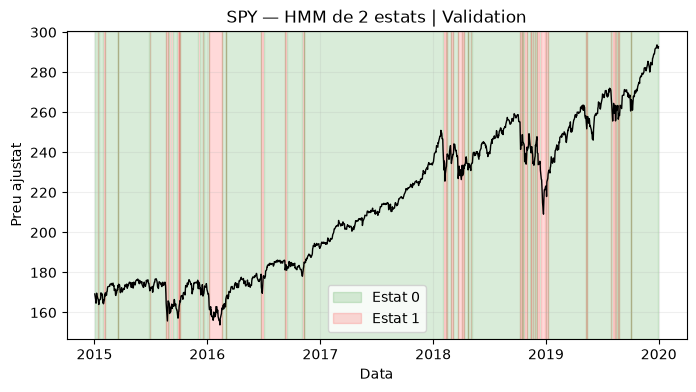


3 estats
Estat 0: 8.0% vol anual
Estat 1: 18.4% vol anual
Estat 2: 44.5% vol anual


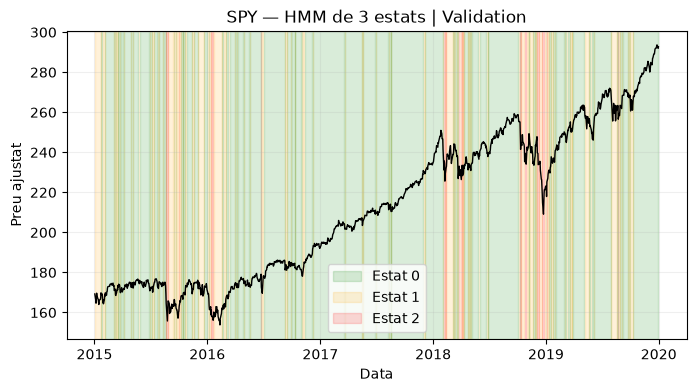


4 estats
Estat 0: 7.6% vol anual
Estat 1: 9.3% vol anual
Estat 2: 21.1% vol anual
Estat 3: 50.6% vol anual


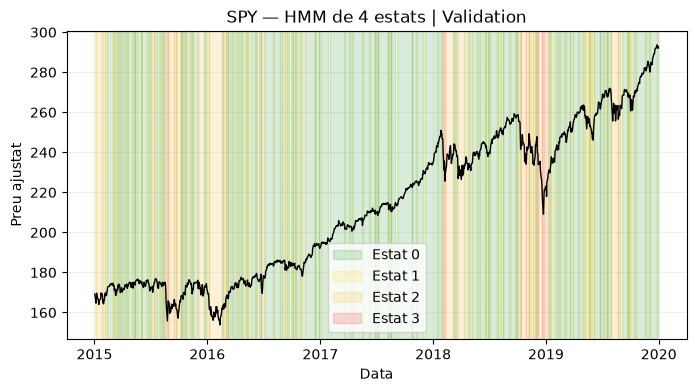

In [24]:
# VISUALITZACIO DELS MODELS DE 2 3 I 4 ESTATS

colors_models = {
    2: ["green", "red"],
    3: ["green", "orange", "red"],
    4: ["green", "gold", "orange", "red"]
}

for k in [2, 3, 4]:

    model = millors_models[k]

    # Filtrat continu train + validation
    prob = probabilitats_filtrades(
        model,
        X_filtrat
    )

    prob_val = prob[len(train):]

    # Volatilitat real de cada estat
    vol_estats = []

    for estat in range(k):

        sigma = (
            np.sqrt(model.covars_[estat][0, 0])
            * scaler.scale_[0]
            * np.sqrt(252)
        )

        vol_estats.append(sigma)

    vol_estats = np.array(vol_estats)

    # Ordenem els estats de menor a major volatilitat
    ordre = np.argsort(vol_estats)

    mapa_estats = {
        estat_original: rang
        for rang, estat_original in enumerate(ordre)
    }

    estat_original = np.argmax(
        prob_val,
        axis=1
    )

    estat_ordenat = np.array([
        mapa_estats[e]
        for e in estat_original
    ])

    print(f"\n{k} estats")

    for rang, estat_original_id in enumerate(ordre):

        print(
            f"Estat {rang}: "
            f"{vol_estats[estat_original_id] * 100:.1f}% vol anual"
        )

    # Gràfic
    fig, ax = plt.subplots(figsize=(8, 4))

    ax.plot(
        validation.index,
        validation["Close"],
        color="black",
        linewidth=1
    )

    for estat in range(k):

        ax.fill_between(
            validation.index,
            0,
            1,
            where=(estat_ordenat == estat),
            transform=ax.get_xaxis_transform(),
            color=colors_models[k][estat],
            alpha=0.15,
            label=f"Estat {estat}"
        )

    ax.set_title(
        f"SPY — HMM de {k} estats | Validation"
    )

    ax.set_xlabel("Data")
    ax.set_ylabel("Preu ajustat")
    ax.legend()
    ax.grid(alpha=0.2)

    plt.show()

## 23. Comparació econòmica entre 2, 3 i 4 estats

Els criteris estadístics i la visualització suggereixen que el model de 3 estats pot representar una estructura natural:

$$
\text{baixa volatilitat}
\rightarrow
\text{volatilitat intermèdia}
\rightarrow
\text{alta volatilitat}
$$

Ara aplicarem exactament la mateixa regla de volatility targeting als models de 2, 3 i 4 estats.

Per evitar afavorir un model simplement perquè assumeix menys risc, escalarem tots els resultats fins a la mateixa volatilitat de Buy & Hold.

Aquesta comparació serà una prova econòmica complementària, no l'únic criteri per escollir el model.

In [25]:
# COMPARACIO ECONOMICA DE 2 3 I 4 ESTATS

comparacio_models = {
    "Buy & Hold": metriques(
        model_risc["Retorn_SPY"]
    )
}

detall_models = []

for k in [2, 3, 4]:

    model = millors_models[k]

    # Probabilitats filtrades
    prob = probabilitats_filtrades(
        model,
        X_filtrat
    )

    prob_val = prob[len(train):]

    # Volatilitat diària de cada estat
    sigma_estats_k = []

    for estat in range(k):

        sigma = (
            np.sqrt(model.covars_[estat][0, 0])
            * scaler.scale_[0]
        )

        sigma_estats_k.append(sigma)

    sigma_estats_k = np.array(
        sigma_estats_k
    )

    # Probabilitat dels estats del dia següent
    prob_seguent = (
        prob_val @ model.transmat_
    )

    # Volatilitat esperada
    variancia_esperada = (
        prob_seguent
        @ (sigma_estats_k ** 2)
    )

    vol_prevista = (
        np.sqrt(variancia_esperada)
        * np.sqrt(252)
    )

    # Volatility targeting
    exposicio = np.minimum(
        0.15 / vol_prevista,
        1.0
    )

    exposicio = pd.Series(
        exposicio,
        index=validation.index
    ).shift(1)

    retorn_model = (
        exposicio
        * validation["Close"].pct_change()
    )

    # Igualem volatilitat a Buy & Hold
    vol_model = (
        retorn_model.std()
        * np.sqrt(252)
    )

    leverage_k = (
        vol_bh / vol_model
    )

    retorn_igual_risc = (
        retorn_model * leverage_k
    )

    comparacio_models[
        f"HMM {k} estats"
    ] = metriques(
        retorn_igual_risc
    )

    detall_models.append({
        "Estats": k,
        "Exposicio_Mitjana": exposicio.mean(),
        "Leverage": leverage_k
    })


resultats_models = pd.DataFrame(
    comparacio_models
).T

resultats_models["CAGR"] *= 100
resultats_models["Volatilitat"] *= 100
resultats_models["Max_Drawdown"] *= 100

detall_models = pd.DataFrame(
    detall_models
).set_index("Estats")

detall_models["Exposicio_Mitjana"] *= 100

display(resultats_models.round(2))

print("\nExposició i leverage:")
display(detall_models.round(2))

,CAGR,Volatilitat,Sharpe,Max_Drawdown
Buy & Hold,11.60,13.43,0.88,-19.35
HMM 2 estats,12.48,13.43,0.94,-16.35
HMM 3 estats,12.99,13.43,0.98,-15.63
HMM 4 estats,12.01,13.43,0.91,-16.47



Exposició i leverage:


,Exposicio_Mitjana,Leverage
Estats,,
2,93.19,1.21
3,92.66,1.22
4,93.37,1.20


## 24. Interpretació del model de 3 estats

El model de 3 estats és actualment el candidat principal.

Abans de continuar, estudiarem què representa cadascun dels règims.

Per cada estat calcularem:

- retorn mitjà;
- volatilitat;
- rang intradiari;
- probabilitat de permanència;
- durada esperada.

La durada esperada d'un estat és:

$$
E[D_i]
=
\frac{1}{1-p_{ii}}
$$

on $p_{ii}$ és la probabilitat de continuar en el mateix estat.

L'objectiu és comprovar si els tres règims tenen una interpretació econòmica clara i diferenciada.

In [26]:
# INTERPRETACIO DEL HMM DE 3 ESTATS

hmm_3 = millors_models[3]

# Paràmetres en escala original
mitjanes_3 = (
    hmm_3.means_ * scaler.scale_
    + scaler.mean_
)

# Ordenem per volatilitat
vols_3 = []

for estat in range(3):

    sigma = (
        np.sqrt(hmm_3.covars_[estat][0, 0])
        * scaler.scale_[0]
    )

    vols_3.append(sigma)

vols_3 = np.array(vols_3)

ordre = np.argsort(vols_3)

files = []

for nou_estat, estat_original in enumerate(ordre):

    permanencia = (
        hmm_3.transmat_[
            estat_original,
            estat_original
        ]
    )

    durada = (
        1 / (1 - permanencia)
    )

    files.append({
        "Estat": nou_estat,
        "Retorn_Mitja_%": (
            mitjanes_3[estat_original, 0] * 100
        ),
        "Vol_Anual_%": (
            vols_3[estat_original]
            * np.sqrt(252)
            * 100
        ),
        "Rang_Mitja_%": (
            mitjanes_3[estat_original, 1] * 100
        ),
        "Permanencia_%": (
            permanencia * 100
        ),
        "Durada_Esperada_dies": durada
    })

resum_3_estats = pd.DataFrame(files).set_index("Estat")

resum_3_estats.round(2)

,Retorn_Mitja_%,Vol_Anual_%,Rang_Mitja_%,Permanencia_%,Durada_Esperada_dies
Estat,,,,,
0,0.13,8.02,0.79,90.73,10.79
1,-0.08,18.38,1.56,86.13,7.21
2,-0.05,44.45,3.48,82.63,5.76


## 25. Transicions entre els tres règims

Ja podem interpretar els tres estats aproximadament com:

$$
0 = \text{calma}
$$

$$
1 = \text{tensió}
$$

$$
2 = \text{estrès}
$$

Ara estudiarem la matriu de transició.

Ens interessa saber, per exemple:

- si les crisis solen arribar passant abans per tensió;
- si el mercat pot saltar directament de calma a estrès;
- com acostuma a sortir d'un règim turbulent.

Això ens permet entendre la dinàmica temporal que està aprenent l'HMM.

In [27]:
# MATRIU DE TRANSICIO DEL HMM DE 3 ESTATS

# Reordenem la matriu segons:
# 0 = baixa vol
# 1 = mitjana vol
# 2 = alta vol

transicio_ordenada = (
    hmm_3.transmat_[ordre][:, ordre]
)

transicio_df = pd.DataFrame(
    transicio_ordenada * 100,
    index=[
        "Des de Calma",
        "Des de Tensio",
        "Des de Estres"
    ],
    columns=[
        "Cap a Calma",
        "Cap a Tensio",
        "Cap a Estres"
    ]
)

display(
    transicio_df.round(2)
)

,Cap a Calma,Cap a Tensio,Cap a Estres
Des de Calma,90.73,9.20,0.07
Des de Tensio,9.21,86.13,4.65
Des de Estres,0.10,17.27,82.63


## 26. Estabilitat de les transicions fora de mostra

La matriu estimada amb train suggereix una estructura clara:

$$
\text{Calma}
\leftrightarrow
\text{Tensió}
\leftrightarrow
\text{Estrès}
$$

Ara comprovarem si els estats filtrats durant validation presenten una dinàmica semblant.

Compararem:

- matriu de transició estimada amb train;
- freqüències de transició observades en els estats filtrats de validation.

Si les dues estructures són semblants, tindrem evidència que la dinàmica dels règims és relativament estable fora de mostra.

In [28]:
# TRANSICIONS FORA DE MOSTRA DEL HMM DE 3 ESTATS

# Probabilitats filtrades train + validation
prob_3 = probabilitats_filtrades(
    hmm_3,
    X_filtrat
)

prob_3_val = prob_3[len(train):]

# Estat més probable
estat_original_val = np.argmax(
    prob_3_val,
    axis=1
)

# Reordenem: 0 calma, 1 tensió, 2 estrès
mapa_estats = {
    estat_original: nou_estat
    for nou_estat, estat_original in enumerate(ordre)
}

estat_val = np.array([
    mapa_estats[e]
    for e in estat_original_val
])

# Comptem transicions
comptes = np.zeros((3, 3))

for t in range(1, len(estat_val)):
    anterior = estat_val[t - 1]
    actual = estat_val[t]

    comptes[anterior, actual] += 1

# Convertim a probabilitats
transicio_validation = (
    comptes
    / comptes.sum(axis=1, keepdims=True)
)

noms = ["Calma", "Tensio", "Estres"]

print("Matriu estimada amb TRAIN (%)")
display(
    pd.DataFrame(
        transicio_ordenada * 100,
        index=noms,
        columns=noms
    ).round(2)
)

print("\nTransicions observades a VALIDATION (%)")
display(
    pd.DataFrame(
        transicio_validation * 100,
        index=noms,
        columns=noms
    ).round(2)
)

Matriu estimada amb TRAIN (%)


,Calma,Tensio,Estres
Calma,90.73,9.20,0.07
Tensio,9.21,86.13,4.65
Estres,0.10,17.27,82.63



Transicions observades a VALIDATION (%)


,Calma,Tensio,Estres
Calma,91.87,7.81,0.33
Tensio,25.85,69.39,4.76
Estres,0.00,41.46,58.54


## 27. Estabilitat de les característiques dels règims

La dinàmica de transicions canvia parcialment fora de mostra, però es manté una estructura important:

$$
\text{Calma}
\leftrightarrow
\text{Tensió}
\leftrightarrow
\text{Estrès}
$$

Ara comprovarem si els tres estats continuen tenint característiques semblants durant validation.

Compararem per cada règim:

- percentatge del temps;
- retorn mitjà;
- volatilitat;
- rang intradiari.

Si l'ordre:

$$
\text{Calma}
<
\text{Tensió}
<
\text{Estrès}
$$

es manté en termes de risc, la interpretació dels règims serà més robusta.

In [29]:
# CARACTERISTIQUES DELS REGIMS A VALIDATION

validation_3 = validation.copy()

validation_3["Estat_HMM"] = estat_val

resum_validation_3 = (
    validation_3
    .groupby("Estat_HMM")
    .agg(
        Dies=("Retorn_Log", "count"),
        Retorn_Mitja=("Retorn_Log", "mean"),
        Volatilitat=("Retorn_Log", "std"),
        Rang_Mitja=("Rang_Log", "mean")
    )
)

resum_validation_3["Percentatge_Temps"] = (
    resum_validation_3["Dies"]
    / len(validation_3)
    * 100
)

resum_validation_3["Retorn_Mitja"] *= 100

resum_validation_3["Volatilitat"] *= (
    np.sqrt(252) * 100
)

resum_validation_3["Rang_Mitja"] *= 100

resum_validation_3.round(2)

,Dies,Retorn_Mitja,Volatilitat,Rang_Mitja,Percentatge_Temps
Estat_HMM,,,,,
0,923,0.10,7.42,0.64,73.37
1,294,-0.04,19.47,1.51,23.37
2,41,-0.70,38.22,3.32,3.26


## 28. Capacitat predictiva de la volatilitat

Els tres règims mantenen característiques semblants fora de mostra.

Ara compararem dues estimacions de risc disponibles en el moment $t$:

1. volatilitat prevista per l'HMM;
2. volatilitat observada durant els últims 20 dies.

Les compararem amb la volatilitat realitzada durant els següents 20 dies.

Utilitzarem:

- correlació;
- MAE;
- RMSE.

L'objectiu és comprovar si l'HMM aporta informació sobre el risc futur més enllà d'una mesura rolling simple.

In [30]:
# PREDICCIO DE VOLATILITAT HMM VS ROLLING

comparacio_vol = validation_hmm.copy()

# Volatilitat futura realitzada a 20 dies
retorns_val = comparacio_vol["Close"].pct_change()

comparacio_vol["Vol_Futura_20d"] = (
    retorns_val
    .rolling(20)
    .std()
    .shift(-20)
    * np.sqrt(252)
)

# Volatilitat rolling coneguda avui
dades_hist = pd.concat([
    train[["Close"]],
    validation[["Close"]]
]).copy()

dades_hist["Retorn"] = (
    dades_hist["Close"].pct_change()
)

dades_hist["Vol_Rolling_20"] = (
    dades_hist["Retorn"]
    .rolling(20)
    .std()
    * np.sqrt(252)
)

comparacio_vol["Vol_Rolling_20"] = (
    dades_hist.loc[
        validation.index,
        "Vol_Rolling_20"
    ]
)

# Predicció de volatilitat del HMM de 3 estats
prob_3 = probabilitats_filtrades(
    hmm_3,
    X_filtrat
)

prob_3_val = prob_3[len(train):]

sigma_3 = []

for estat in range(3):

    sigma = (
        np.sqrt(hmm_3.covars_[estat][0, 0])
        * scaler.scale_[0]
    )

    sigma_3.append(sigma)

sigma_3 = np.array(sigma_3)

prob_seguent_3 = (
    prob_3_val @ hmm_3.transmat_
)

var_prevista_3 = (
    prob_seguent_3
    @ (sigma_3 ** 2)
)

comparacio_vol["Vol_HMM"] = (
    np.sqrt(var_prevista_3)
    * np.sqrt(252)
)

# Eliminem files sense futur complet
avaluacio = comparacio_vol[
    [
        "Vol_Futura_20d",
        "Vol_Rolling_20",
        "Vol_HMM"
    ]
].dropna()

def errors_vol(prediccio, real):
    
    error = prediccio - real
    
    return {
        "Correlacio": prediccio.corr(real),
        "MAE": error.abs().mean(),
        "RMSE": np.sqrt((error ** 2).mean())
    }

resultats_vol = pd.DataFrame({
    "Rolling 20": errors_vol(
        avaluacio["Vol_Rolling_20"],
        avaluacio["Vol_Futura_20d"]
    ),
    
    "HMM 3 estats": errors_vol(
        avaluacio["Vol_HMM"],
        avaluacio["Vol_Futura_20d"]
    )
}).T

resultats_vol *= 100
resultats_vol["Correlacio"] /= 100

resultats_vol.round(3)

,Correlacio,MAE,RMSE
Rolling 20,0.405,4.763,6.741
HMM 3 estats,0.455,4.796,6.703


## 29. HMM walk-forward

Fins ara hem mantingut congelat el model entrenat fins a 2014.

En una aplicació real, els règims i els seus paràmetres poden evolucionar.

Construirem un procés walk-forward anual:

$$
2000-2014
\rightarrow
2015
$$

$$
2000-2015
\rightarrow
2016
$$

$$
2000-2016
\rightarrow
2017
$$

i així successivament.

Cada gener:

1. reentrenarem l'HMM utilitzant només el passat;
2. recalcularem l'escalat;
3. mantindrem 3 estats;
4. seleccionarem la millor inicialització segons train;
5. calcularem probabilitats filtrades;
6. aplicarem volatility targeting amb objectiu del 15%.

No utilitzarem informació futura ni leverage calculat retrospectivament.

In [31]:
# HMM WALK FORWARD ANUAL

resultats_walk = []

for any_actual in range(2015, 2020):

    # Dades disponibles abans de començar l'any
    historic = spy.loc[
        :f"{any_actual - 1}-12-31"
    ].copy()

    dades_any = spy.loc[
        f"{any_actual}-01-01":
        f"{any_actual}-12-31"
    ].copy()

    # Escalat només amb passat
    scaler_wf = StandardScaler()

    X_hist = scaler_wf.fit_transform(
        historic[variables]
    )

    # Busquem la millor seed
    millor_model = None
    millor_loglik = -np.inf

    for seed in range(10):

        model = GaussianHMM(
            n_components=3,
            covariance_type="full",
            n_iter=500,
            random_state=seed
        )

        model.fit(X_hist)

        loglik = model.score(X_hist)

        if loglik > millor_loglik:
            millor_loglik = loglik
            millor_model = model

    # Filtrem història + any actual
    segment = pd.concat([
        historic[variables],
        dades_any[variables]
    ])

    X_segment = scaler_wf.transform(
        segment
    )

    probabilitats = probabilitats_filtrades(
        millor_model,
        X_segment
    )

    # Volatilitat de cada estat
    sigma_estats = []

    for estat in range(3):

        sigma = (
            np.sqrt(
                millor_model.covars_[estat][0, 0]
            )
            * scaler_wf.scale_[0]
        )

        sigma_estats.append(sigma)

    sigma_estats = np.array(
        sigma_estats
    )

    # Probabilitat dels règims del dia següent
    prob_seguent = (
        probabilitats
        @ millor_model.transmat_
    )

    variancia_prevista = (
        prob_seguent
        @ (sigma_estats ** 2)
    )

    vol_prevista = (
        np.sqrt(variancia_prevista)
        * np.sqrt(252)
    )

    # Vol target del 15%, sense superar 100% d'exposició
    exposicio = np.minimum(
        0.15 / vol_prevista,
        1.0
    )

    exposicio = pd.Series(
        exposicio,
        index=segment.index
    ).shift(1)

    # Només guardem l'any actual
    exposicio_any = exposicio.loc[
        dades_any.index
    ]

    retorn_spy = (
        spy["Close"]
        .pct_change()
        .loc[dades_any.index]
    )

    retorn_model = (
        exposicio_any
        * retorn_spy
    )

    resultat_any = pd.DataFrame({
        "Retorn_SPY": retorn_spy,
        "Exposicio": exposicio_any,
        "Retorn_WalkForward": retorn_model
    })

    resultats_walk.append(
        resultat_any
    )


walk_forward = pd.concat(
    resultats_walk
)

print(
    f"Exposició mitjana: "
    f"{walk_forward['Exposicio'].mean():.1%}"
)

resultats_wf = pd.DataFrame({

    "Buy & Hold": metriques(
        walk_forward["Retorn_SPY"]
    ),

    "HMM Walk Forward": metriques(
        walk_forward["Retorn_WalkForward"]
    ),

    "Vol Target simple": metriques(
        simple["Retorn_Model"]
    )

}).T

resultats_wf["CAGR"] *= 100
resultats_wf["Volatilitat"] *= 100
resultats_wf["Max_Drawdown"] *= 100

resultats_wf.round(2)

Exposició mitjana: 92.7%


,CAGR,Volatilitat,Sharpe,Max_Drawdown
Buy & Hold,11.58,13.42,0.88,-19.35
HMM Walk Forward,10.43,11.02,0.96,-13.15
Vol Target simple,9.86,11.63,0.87,-15.34


## 30. Volatility targeting amb leverage dinàmic

Fins ara hem limitat l'exposició màxima a:

$$
w_t \leq 1
$$

Per tant, durant règims molt tranquils el model no podia aprofitar tot el pressupost de risc disponible.

Ara permetrem una exposició màxima de:

$$
w_t \leq 1.5
$$

La regla serà:

$$
w_{t+1}
=
\min
\left(
\frac{\sigma_{objectiu}}
{\hat{\sigma}_{t+1}},
1.5
\right)
$$

Això significa:

- risc baix → exposició superior al 100%;
- risc normal → exposició pròxima al 100%;
- risc elevat → reducció forta de l'exposició.

El leverage es decidirà només amb informació disponible en aquell moment.

De moment estudiarem el resultat brut. Si funciona, després incorporarem el cost real del finançament.

In [39]:
# WALK FORWARD AMB LEVERAGE DINAMIC I PROGRES

resultats_walk_lev = []

vol_objectiu = 0.15
leverage_maxim = 1.5

anys = list(range(2015, 2020))
seeds = list(range(10))

total_passos = len(anys) * len(seeds)
pas_actual = 0

for any_actual in anys:

    historic = spy.loc[
        :f"{any_actual - 1}-12-31"
    ].copy()

    dades_any = spy.loc[
        f"{any_actual}-01-01":
        f"{any_actual}-12-31"
    ].copy()

    # Escalat només amb passat
    scaler_wf = StandardScaler()

    X_hist = scaler_wf.fit_transform(
        historic[variables]
    )

    # Millor HMM segons train
    millor_model = None
    millor_loglik = -np.inf

    for seed in seeds:

        model = GaussianHMM(
            n_components=3,
            covariance_type="full",
            n_iter=500,
            random_state=seed
        )

        model.fit(X_hist)

        loglik = model.score(X_hist)

        if loglik > millor_loglik:
            millor_loglik = loglik
            millor_model = model

        # Progrés global
        pas_actual += 1

        percentatge = (
            pas_actual / total_passos * 100
        )

        print(
            f"\rWalk-forward: "
            f"{percentatge:5.1f}% "
            f"({pas_actual}/{total_passos})",
            end=""
        )

    # Història + any actual
    segment = pd.concat([
        historic[variables],
        dades_any[variables]
    ])

    X_segment = scaler_wf.transform(
        segment
    )

    probabilitats = probabilitats_filtrades(
        millor_model,
        X_segment
    )

    # Volatilitat de cada estat
    sigma_estats = []

    for estat in range(3):

        sigma = (
            np.sqrt(
                millor_model.covars_[estat][0, 0]
            )
            * scaler_wf.scale_[0]
        )

        sigma_estats.append(sigma)

    sigma_estats = np.array(
        sigma_estats
    )

    # Predicció de risc del següent dia
    prob_seguent = (
        probabilitats
        @ millor_model.transmat_
    )

    variancia_prevista = (
        prob_seguent
        @ (sigma_estats ** 2)
    )

    vol_prevista = (
        np.sqrt(variancia_prevista)
        * np.sqrt(252)
    )

    # Exposició amb leverage màxim 1.5x
    exposicio = np.minimum(
        vol_objectiu / vol_prevista,
        leverage_maxim
    )

    exposicio = pd.Series(
        exposicio,
        index=segment.index
    ).shift(1)

    exposicio_any = exposicio.loc[
        dades_any.index
    ]

    retorn_spy = (
        spy["Close"]
        .pct_change()
        .loc[dades_any.index]
    )

    retorn_model = (
        exposicio_any
        * retorn_spy
    )

    resultat_any = pd.DataFrame({
        "Retorn_SPY": retorn_spy,
        "Exposicio": exposicio_any,
        "Retorn_HMM_Leverage": retorn_model
    })

    resultats_walk_lev.append(
        resultat_any
    )

print("\nWalk-forward completat.")

walk_forward_lev = pd.concat(
    resultats_walk_lev
)

resultats_lev = pd.DataFrame({

    "Buy & Hold": metriques(
        walk_forward_lev["Retorn_SPY"]
    ),

    "HMM sense leverage": metriques(
        walk_forward["Retorn_WalkForward"]
    ),

    "HMM leverage max 1.5x": metriques(
        walk_forward_lev["Retorn_HMM_Leverage"]
    )

}).T

resultats_lev["CAGR"] *= 100
resultats_lev["Volatilitat"] *= 100
resultats_lev["Max_Drawdown"] *= 100

print(
    f"\nExposició mitjana: "
    f"{walk_forward_lev['Exposicio'].mean():.2f}x"
)

print(
    f"Exposició màxima: "
    f"{walk_forward_lev['Exposicio'].max():.2f}x"
)

resultats_lev.round(2)

Walk-forward: 100.0% (50/50)
Walk-forward completat.

Exposició mitjana: 1.25x
Exposició màxima: 1.50x


,CAGR,Volatilitat,Sharpe,Max_Drawdown
Buy & Hold,11.58,13.42,0.88,-19.35
HMM sense leverage,10.43,11.02,0.96,-13.15
HMM leverage max 1.5x,14.78,13.78,1.07,-16.93


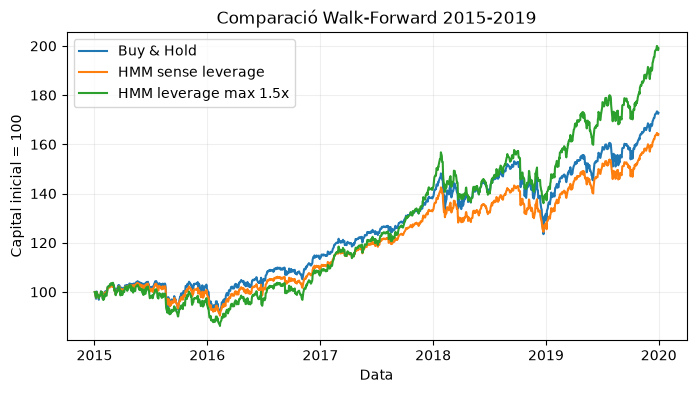

In [40]:
# GRAFIC COMPARATIU DELS 3 MODELS

comparacio_capital = pd.DataFrame(
    index=walk_forward_lev.index
)

comparacio_capital["Buy & Hold"] = (
    100
    * (1 + walk_forward_lev["Retorn_SPY"].fillna(0))
    .cumprod()
)

comparacio_capital["HMM sense leverage"] = (
    100
    * (1 + walk_forward["Retorn_WalkForward"].fillna(0))
    .cumprod()
)

comparacio_capital["HMM leverage max 1.5x"] = (
    100
    * (1 + walk_forward_lev["Retorn_HMM_Leverage"].fillna(0))
    .cumprod()
)

plt.figure(figsize=(8, 4))

plt.plot(
    comparacio_capital.index,
    comparacio_capital["Buy & Hold"],
    label="Buy & Hold"
)

plt.plot(
    comparacio_capital.index,
    comparacio_capital["HMM sense leverage"],
    label="HMM sense leverage"
)

plt.plot(
    comparacio_capital.index,
    comparacio_capital["HMM leverage max 1.5x"],
    label="HMM leverage max 1.5x"
)

plt.title("Comparació Walk-Forward 2015-2019")
plt.xlabel("Data")
plt.ylabel("Capital inicial = 100")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

## 31. Cost del leverage

El leverage no és gratuït.

Quan l'exposició supera el 100%:

$$
w_t > 1
$$

la part extra de la posició necessita finançament.

Per exemple:

$$
w_t=1.30
$$

significa aproximadament:

- 100% capital propi;
- 30% capital finançat.

El cost diari aproximat serà:

$$
Cost_t
=
\max(w_t-1,0)
\frac{r_f}{252}
$$

on $r_f$ és el cost anual del finançament.

Com que aquest cost varia segons l'època i el broker, primer estudiarem una sensibilitat entre 0% i 8% anual.

Això ens permetrà saber quant marge té l'estratègia abans que el leverage deixi de compensar.

In [41]:
# SENSIBILITAT AL COST DEL LEVERAGE

costos_financament = [
    0.00,
    0.02,
    0.04,
    0.06,
    0.08
]

resultats_costos = []

for cost_anual in costos_financament:

    # Només paguem interessos sobre exposició > 1
    capital_prestat = (
        walk_forward_lev["Exposicio"] - 1
    ).clip(lower=0)

    cost_diari = (
        capital_prestat
        * cost_anual
        / 252
    )

    retorn_net = (
        walk_forward_lev["Retorn_HMM_Leverage"]
        - cost_diari
    )

    m = metriques(retorn_net)

    resultats_costos.append({
        "Cost_Financament_%": cost_anual * 100,
        "CAGR": m["CAGR"] * 100,
        "Volatilitat": m["Volatilitat"] * 100,
        "Sharpe": m["Sharpe"],
        "Max_Drawdown": m["Max_Drawdown"] * 100
    })

resultats_costos = pd.DataFrame(
    resultats_costos
).set_index("Cost_Financament_%")

resultats_costos.round(2)

,CAGR,Volatilitat,Sharpe,Max_Drawdown
Cost_Financament_%,,,,
0.0,14.78,13.78,1.07,-16.93
2.0,14.04,13.78,1.02,-17.30
4.0,13.31,13.78,0.98,-17.66
6.0,12.59,13.78,0.93,-18.03
8.0,11.86,13.78,0.88,-18.39


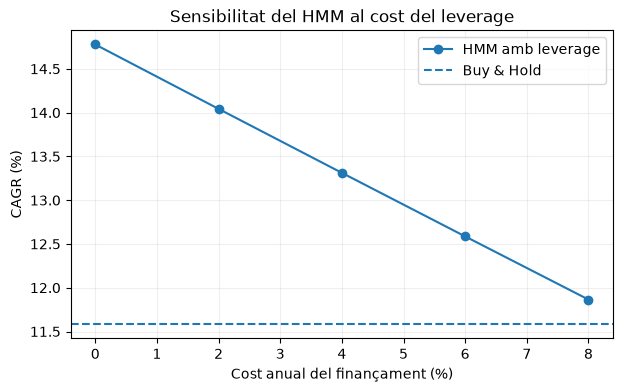

In [42]:
# IMPACTE DEL COST DE FINANCAMENT

plt.figure(figsize=(7, 4))

plt.plot(
    resultats_costos.index,
    resultats_costos["CAGR"],
    marker="o",
    label="HMM amb leverage"
)

plt.axhline(
    11.58,
    linestyle="--",
    label="Buy & Hold"
)

plt.xlabel("Cost anual del finançament (%)")
plt.ylabel("CAGR (%)")
plt.title("Sensibilitat del HMM al cost del leverage")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

## 32. Turnover i costos reals

El model modifica l'exposició cada dia.

Això genera turnover:

$$
Turnover_t = |w_t-w_{t-1}|
$$

Aplicarem dos costos:

1. finançament anual del leverage del 5%;
2. cost de transacció sobre cada canvi d'exposició.

Provarem:

$$
0,\ 1,\ 2,\ 5,\ 10
$$

bps per unitat de turnover.

L'objectiu és comprovar si l'avantatge del model continua existint després de friccions.

In [43]:
# COSTOS DE FINANCAMENT I TURNOVER

cost_financament_anual = 0.05
costos_bps = [0, 1, 2, 5, 10]

costos = walk_forward_lev.copy()

# Capital prestat
costos["Capital_Prestat"] = (
    costos["Exposicio"] - 1
).clip(lower=0)

# Cost diari de finançament
costos["Cost_Financament"] = (
    costos["Capital_Prestat"]
    * cost_financament_anual
    / 252
)

# Aproximació del turnover pels canvis d'exposició
costos["Turnover"] = (
    costos["Exposicio"]
    .diff()
    .abs()
)

costos.iloc[
    costos.columns.get_loc("Turnover") * 0
]

costos["Turnover"] = costos["Turnover"].fillna(
    costos["Exposicio"].iloc[0]
)

resultats_friccions = []

for bps in costos_bps:

    cost_transaccio = (
        costos["Turnover"]
        * bps
        / 10000
    )

    retorn_net = (
        costos["Retorn_HMM_Leverage"]
        - costos["Cost_Financament"]
        - cost_transaccio
    )

    m = metriques(retorn_net)

    resultats_friccions.append({
        "Cost_bps": bps,
        "CAGR": m["CAGR"] * 100,
        "Volatilitat": m["Volatilitat"] * 100,
        "Sharpe": m["Sharpe"],
        "Max_Drawdown": m["Max_Drawdown"] * 100
    })

resultats_friccions = pd.DataFrame(
    resultats_friccions
).set_index("Cost_bps")

anys_backtest = len(costos) / 252

print(
    f"Turnover total: "
    f"{costos['Turnover'].sum():.1f}x capital"
)

print(
    f"Turnover anual aproximat: "
    f"{costos['Turnover'].sum() / anys_backtest:.1f}x"
)

display(
    resultats_friccions.round(2)
)

Turnover total: 140.1x capital
Turnover anual aproximat: 28.1x


,CAGR,Volatilitat,Sharpe,Max_Drawdown
Cost_bps,,,,
0,12.95,13.78,0.95,-17.85
1,12.63,13.78,0.93,-18.15
2,12.32,13.78,0.91,-18.46
5,11.38,13.78,0.85,-19.36
10,9.82,13.79,0.75,-20.86


## 33. Configuració final abans del test

Després de validation, congelem la configuració:

- HMM de 3 estats;
- variables: retorn logarítmic i rang intradiari;
- entrenament expanding;
- reentrenament anual;
- 10 inicialitzacions i selecció per log-versemblança de train;
- volatility target del 15%;
- leverage màxim de 1.5x;
- cost de finançament del 5% anual sobre la part finançada;
- cost de transacció base de 2 bps per unitat de turnover.

No modificarem aquests paràmetres després de veure el test.

Compararem contra:

1. Buy & Hold;
2. volatility targeting rolling de 20 dies amb les mateixes regles de leverage i costos;
3. HMM walk-forward.

Ara obrirem per primera vegada el període de test:

$$
2020 \rightarrow \text{actualitat}
$$

In [44]:
# TEST FINAL WALK FORWARD

vol_objectiu = 0.15
leverage_maxim = 1.5

cost_financament = 0.05
cost_transaccio_bps = 2

anys_test = sorted(
    test.index.year.unique()
)

seeds = list(range(10))

total_passos = (
    len(anys_test) * len(seeds)
)

pas_actual = 0

resultats_test = []

for any_actual in anys_test:

    historic = spy.loc[
        :f"{any_actual - 1}-12-31"
    ].copy()

    dades_any = test.loc[
        test.index.year == any_actual
    ].copy()

    # Escalat només amb passat
    scaler_wf = StandardScaler()

    X_hist = scaler_wf.fit_transform(
        historic[variables]
    )

    # Millor HMM del train
    millor_model = None
    millor_loglik = -np.inf

    for seed in seeds:

        model = GaussianHMM(
            n_components=3,
            covariance_type="full",
            n_iter=500,
            random_state=seed
        )

        model.fit(X_hist)

        loglik = model.score(X_hist)

        if loglik > millor_loglik:
            millor_loglik = loglik
            millor_model = model

        pas_actual += 1

        print(
            f"\rTest walk-forward: "
            f"{pas_actual / total_passos * 100:5.1f}% "
            f"({pas_actual}/{total_passos})",
            end=""
        )

    # Filtrat continu
    segment = pd.concat([
        historic[variables],
        dades_any[variables]
    ])

    X_segment = scaler_wf.transform(
        segment
    )

    prob = probabilitats_filtrades(
        millor_model,
        X_segment
    )

    # Volatilitat de cada estat
    sigma_estats = []

    for estat in range(3):

        sigma = (
            np.sqrt(
                millor_model.covars_[estat][0, 0]
            )
            * scaler_wf.scale_[0]
        )

        sigma_estats.append(sigma)

    sigma_estats = np.array(
        sigma_estats
    )

    # Predicció de risc de t+1
    prob_seguent = (
        prob @ millor_model.transmat_
    )

    var_prevista = (
        prob_seguent
        @ (sigma_estats ** 2)
    )

    vol_prevista = (
        np.sqrt(var_prevista)
        * np.sqrt(252)
    )

    exposicio = np.minimum(
        vol_objectiu / vol_prevista,
        leverage_maxim
    )

    # Decisió de t aplicada a t+1
    exposicio = pd.Series(
        exposicio,
        index=segment.index
    ).shift(1)

    exposicio_any = exposicio.loc[
        dades_any.index
    ]

    retorn_spy = (
        spy["Close"]
        .pct_change()
        .loc[dades_any.index]
    )

    resultat = pd.DataFrame({
        "Retorn_SPY": retorn_spy,
        "Exposicio_HMM": exposicio_any
    })

    resultats_test.append(
        resultat
    )

print("\nTest completat.")

test_final = pd.concat(
    resultats_test
)

# Retorn brut HMM
test_final["Retorn_HMM_Brut"] = (
    test_final["Exposicio_HMM"]
    * test_final["Retorn_SPY"]
)

# Cost de finançament
test_final["Cost_Fin_HMM"] = (
    (test_final["Exposicio_HMM"] - 1)
    .clip(lower=0)
    * cost_financament
    / 252
)

# Turnover
test_final["Turnover_HMM"] = (
    test_final["Exposicio_HMM"]
    .diff()
    .abs()
    .fillna(0)
)

test_final["Cost_Trading_HMM"] = (
    test_final["Turnover_HMM"]
    * cost_transaccio_bps
    / 10000
)

test_final["Retorn_HMM_Net"] = (
    test_final["Retorn_HMM_Brut"]
    - test_final["Cost_Fin_HMM"]
    - test_final["Cost_Trading_HMM"]
)


# BASELINE SIMPLE AMB LES MATEIXES REGLES

simple_test = spy.loc[
    :test.index.max()
].copy()

simple_test["Retorn"] = (
    simple_test["Close"].pct_change()
)

simple_test["Vol_20"] = (
    simple_test["Retorn"]
    .rolling(20)
    .std()
    * np.sqrt(252)
)

simple_test["Exposicio"] = (
    vol_objectiu
    / simple_test["Vol_20"]
).clip(
    upper=leverage_maxim
).shift(1)

simple_test = simple_test.loc[
    test.index
].copy()

simple_test["Retorn_Brut"] = (
    simple_test["Exposicio"]
    * simple_test["Retorn"]
)

simple_test["Cost_Fin"] = (
    (simple_test["Exposicio"] - 1)
    .clip(lower=0)
    * cost_financament
    / 252
)

simple_test["Turnover"] = (
    simple_test["Exposicio"]
    .diff()
    .abs()
    .fillna(0)
)

simple_test["Cost_Trading"] = (
    simple_test["Turnover"]
    * cost_transaccio_bps
    / 10000
)

simple_test["Retorn_Net"] = (
    simple_test["Retorn_Brut"]
    - simple_test["Cost_Fin"]
    - simple_test["Cost_Trading"]
)


# METRIQUES FINALS

resultats_test_final = pd.DataFrame({

    "Buy & Hold":
        metriques(
            test_final["Retorn_SPY"]
        ),

    "Vol Target simple":
        metriques(
            simple_test["Retorn_Net"]
        ),

    "HMM 3 estats":
        metriques(
            test_final["Retorn_HMM_Net"]
        )

}).T

resultats_test_final["CAGR"] *= 100
resultats_test_final["Volatilitat"] *= 100
resultats_test_final["Max_Drawdown"] *= 100

print(
    f"\nExposició mitjana HMM: "
    f"{test_final['Exposicio_HMM'].mean():.2f}x"
)

print(
    f"Turnover anual HMM: "
    f"{test_final['Turnover_HMM'].sum() / (len(test_final) / 252):.1f}x"
)

display(
    resultats_test_final.round(2)
)

Test walk-forward: 100.0% (70/70)
Test completat.

Exposició mitjana HMM: 1.05x
Turnover anual HMM: 37.4x


,CAGR,Volatilitat,Sharpe,Max_Drawdown
Buy & Hold,15.28,20.04,0.81,-33.72
Vol Target simple,13.76,15.91,0.89,-18.94
HMM 3 estats,12.15,15.54,0.82,-19.34


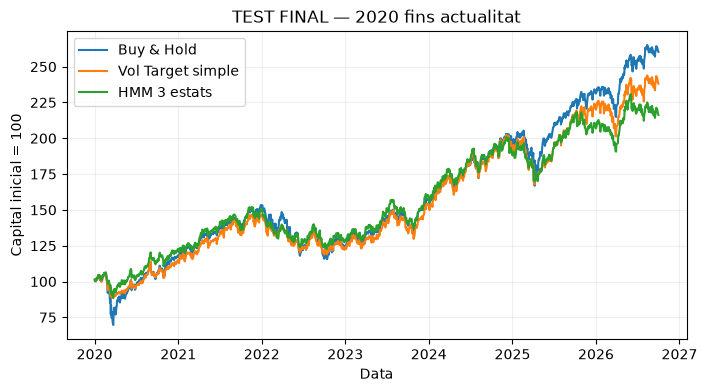

In [45]:
# GRAFIC DEL TEST FINAL

capital_test = pd.DataFrame(
    index=test_final.index
)

capital_test["Buy & Hold"] = (
    100
    * (1 + test_final["Retorn_SPY"].fillna(0))
    .cumprod()
)

capital_test["Vol Target simple"] = (
    100
    * (1 + simple_test["Retorn_Net"].fillna(0))
    .cumprod()
)

capital_test["HMM 3 estats"] = (
    100
    * (1 + test_final["Retorn_HMM_Net"].fillna(0))
    .cumprod()
)

plt.figure(figsize=(8, 4))

plt.plot(
    capital_test.index,
    capital_test["Buy & Hold"],
    label="Buy & Hold"
)

plt.plot(
    capital_test.index,
    capital_test["Vol Target simple"],
    label="Vol Target simple"
)

plt.plot(
    capital_test.index,
    capital_test["HMM 3 estats"],
    label="HMM 3 estats"
)

plt.title("TEST FINAL — 2020 fins actualitat")
plt.xlabel("Data")
plt.ylabel("Capital inicial = 100")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

## 34. Diagnòstic final: on perd l'HMM?

El test final mostra que l'HMM redueix fortament el risc respecte Buy & Hold, però no supera un volatility targeting simple.

Per entendre el motiu, separarem el test any per any.

Compararem:

- rendiment de Buy & Hold;
- rendiment del Vol Target simple;
- rendiment de l'HMM;
- exposició mitjana de cada model.

No modificarem cap paràmetre després d'aquest diagnòstic.

L'objectiu és entendre el resultat, no tornar a optimitzar el model.

,Buy & Hold,Vol Target simple,HMM 3 estats,HMM - Simple,Exposicio Simple,Exposicio HMM
Date,,,,,,
2020,18.33,15.13,22.89,7.75,0.83,0.88
2021,28.73,26.46,21.35,-5.12,1.23,1.20
2022,-18.18,-15.27,-13.58,1.69,0.67,0.68
2023,26.18,24.68,23.97,-0.71,1.18,1.09
2024,24.89,25.00,17.92,-7.09,1.27,1.21
2025,17.72,14.38,9.79,-4.59,1.11,1.12
2026,12.59,8.28,4.59,-3.69,1.21,1.17


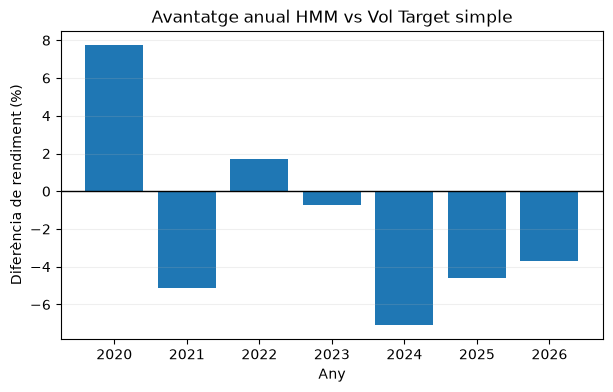

In [46]:
# DIAGNOSTIC FINAL ANY A ANY

diagnostic = pd.DataFrame(
    index=test_final.index
)

diagnostic["Buy & Hold"] = (
    test_final["Retorn_SPY"]
)

diagnostic["Vol Target simple"] = (
    simple_test["Retorn_Net"]
)

diagnostic["HMM 3 estats"] = (
    test_final["Retorn_HMM_Net"]
)

diagnostic["Exposicio Simple"] = (
    simple_test["Exposicio"]
)

diagnostic["Exposicio HMM"] = (
    test_final["Exposicio_HMM"]
)


# Retorns anuals
retorns_anuals_test = (
    diagnostic[
        [
            "Buy & Hold",
            "Vol Target simple",
            "HMM 3 estats"
        ]
    ]
    .groupby(diagnostic.index.year)
    .apply(
        lambda x: (1 + x).prod() - 1
    )
    * 100
)

retorns_anuals_test["HMM - Simple"] = (
    retorns_anuals_test["HMM 3 estats"]
    - retorns_anuals_test["Vol Target simple"]
)


# Exposicions anuals
exposicions_anuals = (
    diagnostic[
        [
            "Exposicio Simple",
            "Exposicio HMM"
        ]
    ]
    .groupby(diagnostic.index.year)
    .mean()
)

resultat_anual = pd.concat(
    [
        retorns_anuals_test,
        exposicions_anuals
    ],
    axis=1
)

display(
    resultat_anual.round(2)
)


# Gràfic de la diferència HMM vs Simple

plt.figure(figsize=(7, 4))

plt.bar(
    retorns_anuals_test.index.astype(str),
    retorns_anuals_test["HMM - Simple"]
)

plt.axhline(
    0,
    color="black",
    linewidth=1
)

plt.title("Avantatge anual HMM vs Vol Target simple")
plt.xlabel("Any")
plt.ylabel("Diferència de rendiment (%)")
plt.grid(
    axis="y",
    alpha=0.2
)

plt.show()

## 35. Conclusió de l'aplicació HMM

El Hidden Markov Model ha identificat una estructura de tres règims robusta i interpretable:

$$
\text{Calma}
\leftrightarrow
\text{Tensió}
\leftrightarrow
\text{Estrès}
$$

Aquests règims es mantenen fora de mostra i contenen informació sobre la volatilitat futura.

L'HMM també ha estat útil per reduir risc:

- menor volatilitat;
- menor drawdown;
- protecció especialment bona en episodis com 2020 i 2022.

Tanmateix, en el test final no supera un volatility targeting rolling de 20 dies.

El principal problema sembla ser que la persistència dels règims fa que l'HMM adapti l'exposició més lentament quan el risc disminueix.

Això penalitza especialment els períodes alcistes persistents i les recuperacions.

Per tant:

$$
\boxed{
\text{HMM útil per entendre i detectar règims}
}
$$

però:

$$
\boxed{
\text{HMM Vol Target}
\not>
\text{Vol Target simple}
}
$$

en aquesta aplicació concreta.

No modificarem els paràmetres després d'haver observat el test.

El model es conserva com una eina interessant de detecció de règims, però aquesta estratègia de position sizing queda tancada.